# Exam Hand-In - Data and Things
**Jonas Wolffrom Strandgaard Clausen - jwsc@ruc.dk**

Disclosure: I had an AI (Claude 4.6) port over my exercises to this notebook and filled in the exercises that didn't get added right. Everything should be okay, but in case something looks a little odd formatting wise, that's why. 

## Imports and Setup

In [43]:
%matplotlib inline

# Standard and math imports
import os
import subprocess
import threading
import time
import tempfile
import numpy as np
import pandas as pd
import IPython.display as ip_display
import re

# Plotting libs
import matplotlib.pyplot as plt
import seaborn as sns

# Data Science libs
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Machine Learning libs
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
import statsmodels.api as sm
import shap
import lime
from lime import lime_tabular
import networkx as nx
import paho.mqtt.client as mqtt

# Polars
import polars as pl

# XGBoost
from xgboost import XGBRegressor, XGBClassifier

# MLFlow
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# Sklearn imports
import sklearn

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, f1_score, silhouette_score,
    roc_curve, roc_auc_score,
    mean_squared_error, mean_absolute_error, adjusted_rand_score, classification_report
)
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.base import clone

# Keras / Deep learning
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
from keras import layers
from keras.datasets import imdb, reuters
from keras.utils import to_categorical


---
# 1. Data Transformation and Exploratory Data Analysis (EDA)

**Exercise:** Do an exploratory data analysis of the adult dataset.

**Requirements:**
- Explain what the data is about and which variables the dataset contains
- Explain data types of each variable
- Investigate distribution/variation through visualization and descriptive statistics for each individual variable
- Investigate variation/correlation between pairs of variables:
  - One case where both variables are categorical
  - One case where both variables are numeric
  - One case where one is categorical and one is numeric

## Load and Explore Adult Dataset

In [44]:
adults = pd.read_csv("Data/adult.csv")
adults.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Dataset Overview and Variable Types

In [45]:
# Dataset information
print("Dataset Shape:", adults.shape)
print("\nColumn Data Types:")
print(adults.dtypes)
print("\nDataset Info:")
adults.info()
print("\nDescriptive Statistics:")
adults.describe()

Dataset Shape: (48842, 15)

Column Data Types:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


## Individual Variable Analysis

### Age Analysis

In [46]:
# Mean age analysis
mean_age = adults["age"].mean()
male_age = adults[adults["sex"] == "Male"]["age"]
mean_male_age = male_age.mean()
female_age = adults[adults["sex"] == "Female"]["age"]
mean_female_age = female_age.mean()

print(f"Overall mean age: {mean_age:.2f}")
print(f"Mean male age: {mean_male_age:.2f}")
print(f"Mean female age: {mean_female_age:.2f}")
print(f"Age difference (Male - Female): {mean_male_age - mean_female_age:.2f}")

Overall mean age: 38.64
Mean male age: 39.49
Mean female age: 36.93
Age difference (Male - Female): 2.57


### Education Analysis

Education Distribution:
       education  people_count
0        HS-grad         15784
1   Some-college         10878
2      Bachelors          8025
3        Masters          2657
4      Assoc-voc          2061
5           11th          1812
6     Assoc-acdm          1601
7           10th          1389
8        7th-8th           955
9    Prof-school           834
10           9th           756
11          12th           657
12     Doctorate           594
13       5th-6th           509
14       1st-4th           247
15     Preschool            83


<Figure size 1200x600 with 0 Axes>

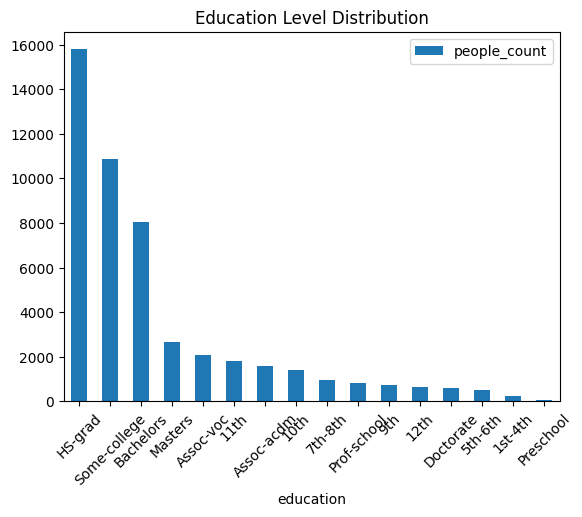

In [47]:
# Education types and counts
educations = adults["education"].value_counts().reset_index()
educations.columns = ["education", "people_count"]
print("Education Distribution:")
print(educations)

# Visualize education distribution
plt.figure(figsize=(12, 6))
educations.plot(x="education", y="people_count", kind="bar", title="Education Level Distribution")
plt.xticks(rotation=45)
plt.show()

## Pairwise Variable Analysis

### Case 1: Both Categorical - Sex vs Education Level

In [48]:
# Education level comparison by sex
male_education_levels = adults[adults["sex"] == "Male"]["education-num"]
mean_male_education_level = male_education_levels.mean()

female_education_levels = adults[adults["sex"] == "Female"]["education-num"]
mean_female_education_level = female_education_levels.mean()

print(f"Mean education level (Male): {mean_male_education_level:.2f}")
print(f"Mean education level (Female): {mean_female_education_level:.2f}")
print(f"Difference: {mean_male_education_level - mean_female_education_level:.2f}")

Mean education level (Male): 10.09
Mean education level (Female): 10.04
Difference: 0.05


### Case 2: Both Numeric - Age vs Hours Worked

Correlation between age and hours per week: 0.0716


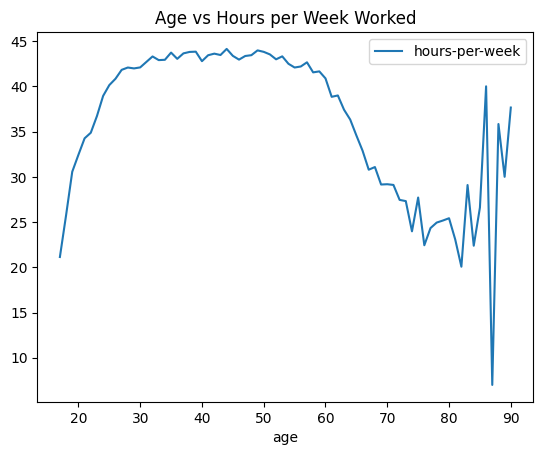

In [49]:
# Correlation between age and hours worked
age_vs_work_hours = pd.DataFrame()
age_vs_work_hours["age"] = adults["age"]
age_vs_work_hours["hours-per-week"] = adults["hours-per-week"]

correlation = age_vs_work_hours["age"].corr(age_vs_work_hours["hours-per-week"])
print(f"Correlation between age and hours per week: {correlation:.4f}")

# Visualize
grouped_age_vs_work_hours = age_vs_work_hours.groupby("age").mean().reset_index()
grouped_age_vs_work_hours.plot(x="age", y="hours-per-week", kind="line", 
                                title="Age vs Hours per Week Worked")
plt.show()

### Case 3: Categorical vs Numeric - Sex vs Income

Income distribution by sex:
income     sex  <=50K  <=50K.  >50K  >50K.
0       Female   9592    4831  1179    590
1         Male  15128    7604  6662   3256


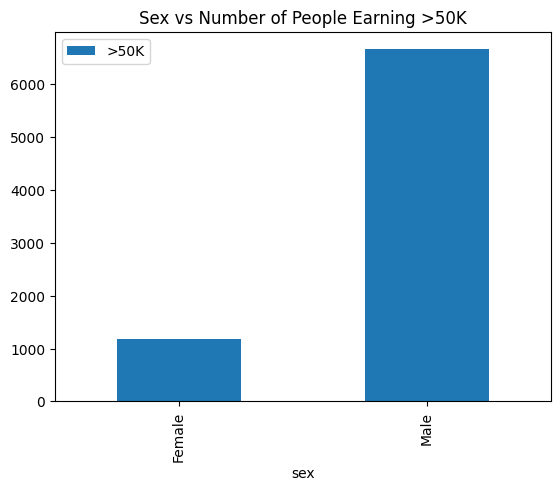

In [50]:
# Income comparison by sex
income_by_sex = pd.DataFrame()
income_by_sex["sex"] = adults["sex"]
income_by_sex["income"] = adults["income"]

grouped_income_by_sex = income_by_sex.groupby("sex").value_counts().unstack().reset_index()
print("Income distribution by sex:")
print(grouped_income_by_sex)

# Visualize
grouped_income_by_sex.plot(x="sex", y=">50K", kind="bar", 
                           title="Sex vs Number of People Earning >50K")
plt.show()

---
# 2. Statistics

Load in the data "energySoftware.csv" and answer the following questions:
1. Plot the distribution of CPU for each test type
2. Is there a difference in the CPU between bubblesort and bubblesort_ll? (note that the last name contains two small l's and not two capital i's) Justify your choice of test(s). 
3. Is there a difference in the CPU between bubblesort_func and bubblesort_ll2? Justify your choice of test(s). If there is a difference, how big is it?
4. When it comes to time, is there a difference between bubblesort and bubblesort_ll? Justify your choice of test(s).
5. Perform an ANOVA test to test if there is a difference in means across groups for time

In [111]:
# Load the dataset

energy = pd.read_csv("Data/energySoftware.csv")
energy.head()

,test,PKG,CPU,nn,nn2,time
0,bubblesort,0.010986,0.009155,,,3.165
1,bubblesort,0.013184,0.010925,,,3.069
2,bubblesort,0.015198,0.009399,,,2.617
3,bubblesort,0.010559,0.009583,,,2.572
4,bubblesort,0.009949,0.009949,,,2.671


In [112]:
# Separate entries by test type
bubblesort = energy[energy["test"] == "bubblesort"].dropna()
bubblesort2 = energy[energy["test"] == "bubblesort_ll"].dropna()

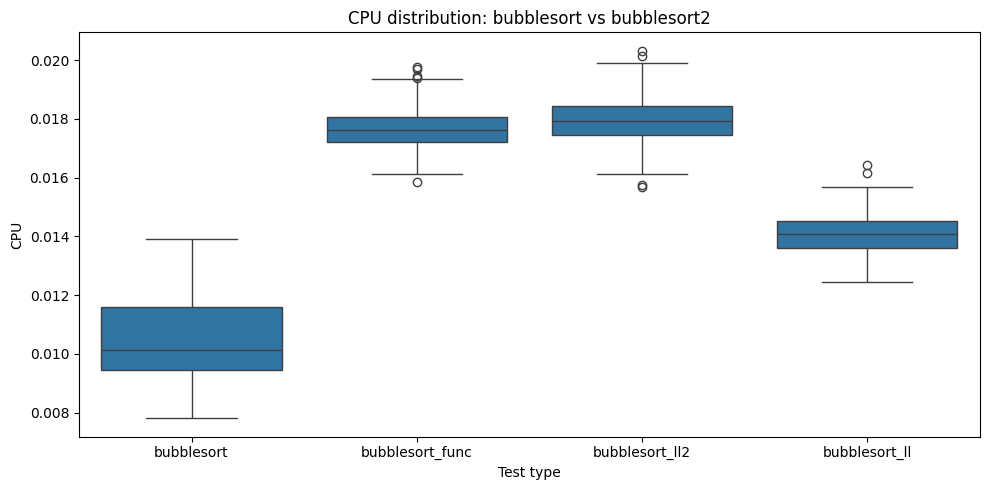

In [113]:
# Plot each distribution by test type
plt.figure(figsize=(10, 5))
sns.boxplot(data=energy, x="test", y="CPU")
plt.title("CPU distribution: bubblesort vs bubblesort2")
plt.xlabel("Test type")
plt.ylabel("CPU")
plt.tight_layout()
plt.show()

From the graph we can see that the bubblesort CPU metrics are somewhat shifted from the middle, but we need to ensure what we see with a shapiro-test. As such, we assume that that both bubblesort and bubblesort_ii CPU metrics are normally distributed

In [114]:
# Shapiro test for normality
statistic, p_value = stats.shapiro(bubblesort["CPU"])
print("Shapiro-Wilk Test for Bubblesort CPU:")
print("T-statistic:", statistic)
print("P-value:", p_value)

statistic, p_value = stats.shapiro(bubblesort2["CPU"])
print("Shapiro-Wilk Test for Bubblesort2 CPU:")
print("T-statistic:", statistic)
print("P-value:", p_value)

Shapiro-Wilk Test for Bubblesort CPU:
T-statistic: 0.97149957608177
P-value: 1.5722188157994535e-06
Shapiro-Wilk Test for Bubblesort2 CPU:
T-statistic: 0.9948246948673037
P-value: 0.26921286581817916


Seeing as the p-value for Bubblesort CPU is much lower than 0.05, we reject the null hypothesis that both are normally distributed, we can see just bubblesort2 has a normal distribution, meaning we can use a Mann-Whitney U test.

H₀: There is no difference in the CPU metrics between bubblesort and bubblesort_ii
    (μ_Bubblesort = μ_Bubblesort_ii)

H₁: There is a difference in the CPU metrics between bubblesort and bubblesort_ii
    (μ_Bubblesort ≠ μ_Bubblesort_ii)

α = 0.05

In [115]:
# Mann-Whitney U Test
u_statistic, p_value_u = stats.mannwhitneyu(bubblesort["CPU"], bubblesort2["CPU"])
print("Mann-Whitney U Test between Bubblesort and Bubblesort2 CPU:")
print("U-statistic:", u_statistic)
print("P-value:", p_value_u)

Mann-Whitney U Test between Bubblesort and Bubblesort2 CPU:
U-statistic: 645.5
P-value: 3.79156286604797e-117


With the correlation value being this low, the results strongly reject the Null hypothesis, suggesting there very likely is a difference in the CPU metrics of Bubblesort and Bubblesort_ii

In [116]:
# Separate other test types
bubblesort_func = energy[energy["test"] == "bubblesort_func"].dropna()
bubblesort_ll2 = energy[energy["test"] == "bubblesort_ll2"].dropna()

We see that both bubblesort_func and bubblesort_ll2 are very similar on the graph, but again we test to ensure they are normally distributed.

In [117]:
# Shapiro test for normality
statistic, p_value = stats.shapiro(bubblesort_func["CPU"].dropna())
print("Shapiro-Wilk Test for Bubblesort_func CPU:")
print("T-statistic:", statistic)
print("P-value:", p_value)

statistic, p_value = stats.shapiro(bubblesort_ll2["CPU"].dropna())
print("Shapiro-Wilk Test for Bubblesort_ll2 CPU:")
print("T-statistic:", statistic)
print("P-value:", p_value)  

Shapiro-Wilk Test for Bubblesort_func CPU:
T-statistic: 0.994501031538344
P-value: 0.22397701570892709
Shapiro-Wilk Test for Bubblesort_ll2 CPU:
T-statistic: 0.9948558743196282
P-value: 0.27395759572988476


Seeing as the p-value for Bubblesort_func and Bubblesort_ii2 are both well ablove the 0.05 acceptance criteria, we can assume they are both normally distributed, so we use a T-test to check whether or not there is a difference between their CPU metrics.

H₀: There is no difference in the CPU metrics between bubblesort_func and bubblesort_ii2
    (μ_Bubblesort = μ_Bubblesort_ii)

H₁: There is a difference in the CPU metrics between bubblesort_func and bubblesort_ii2
    (μ_Bubblesort ≠ μ_Bubblesort_ii)

α = 0.05

In [118]:
# T-test between bubblesort_func and bubblesort_ll2
t_statistic, p_value_t = stats.ttest_ind(bubblesort_func["CPU"], bubblesort_ll2["CPU"], equal_var=False)
print("T-test between Bubblesort_func and Bubblesort_ll2 CPU:")
print("T-statistic:", t_statistic)
print("P-value:", p_value_t)

T-test between Bubblesort_func and Bubblesort_ll2 CPU:
T-statistic: -4.692273179928858
P-value: 3.246796360135073e-06


Seeing as we have a p-value below 0.05 for the T-test, assuming both are inequal, we can reject the Null Hypothesis and say it's likely there are no differences in CPU metrics between the datasets.

In [119]:
# Testing between bubblesort and bubblesort_ii for time, assuming they are normally distributed
statistic, p_value = stats.shapiro(bubblesort["time"].dropna())
print("Shapiro-Wilk Test for Bubblesort time:")
print("T-statistic:", statistic)
print("P-value:", p_value)

statistic, p_value = stats.shapiro(bubblesort2["time"].dropna())
print("Shapiro-Wilk Test for Bubblesort2 time:")
print("T-statistic:", statistic)
print("P-value:", p_value)

Shapiro-Wilk Test for Bubblesort time:
T-statistic: 0.9174711482830614
P-value: 3.5117387717841384e-13
Shapiro-Wilk Test for Bubblesort2 time:
T-statistic: 0.7900392858871499
P-value: 3.2014552851553314e-21


In [120]:
# Using Mann-Whitney U Test for time comparison as they are not normally distributed, assuming their distributions differ
u_statistic_time, p_value_u_time = stats.mannwhitneyu(bubblesort["time"], bubblesort2["time"])
print("Mann-Whitney U Test between Bubblesort and Bubblesort2 time:")
print("U-statistic:", u_statistic_time)
print("P-value:", p_value_u_time)

Mann-Whitney U Test between Bubblesort and Bubblesort2 time:
U-statistic: 74960.0
P-value: 0.00035855213302219286


With this p value below 0.05 it suggests that the distributions between bubblesort and bubblesort2 time metrics differ, so we accept the null hypothesis.

In [121]:
# Use the ANOVA test to compare all four groups for time
f_statistic, p_value_anova = stats.f_oneway(bubblesort["time"], bubblesort2["time"], 
                                              bubblesort_func["time"], bubblesort_ll2["time"])
print("ANOVA Test for time across all four groups:")
print("F-statistic:", f_statistic)
print("P-value:", p_value_anova)

ANOVA Test for time across all four groups:
F-statistic: 2556.3329354127864
P-value: 0.0


The ANOVA F-statistic of 2556.33 with a p-value effectively at zero means we strongly reject H₀.

**H₀:** The mean `time` is equal across all four groups (bubblesort, bubblesort_ll, bubblesort_func, bubblesort_ll2)
**H₁:** At least one group has a different mean `time`

With a p-value far below α = 0.05, we conclude there is a statistically significant difference in mean execution time across at least one pair of groups

Note: Since the time data was shown to be non-normally distributed (Shapiro-Wilk, exercise 2.4), ANOVA's normality assumption is technically violated. However, with an F-statistic this extreme, the conclusion would be identical. ANOVA is also generally robust with large sample sizes.

---
# 3. Data Engineering

**Exercise:** Task 7 from Exercise 4 — Wrap the full Online Retail data pipeline into an ETL function.


In [55]:
def etl(dataset_path:str):
    path = kagglehub.dataset_download(dataset_path)
    files = os.listdir(path)
    file_path = os.path.join(path, files[0])

    online_retail = pd.read_excel(file_path)

    online_retail_cleaned = online_retail.copy()
    online_retail_cleaned = online_retail_cleaned.dropna()
    online_retail_cleaned = online_retail_cleaned[online_retail_cleaned["Quantity"] > 0]
    online_retail_cleaned = online_retail_cleaned[online_retail_cleaned["Price"] > 0]

    # Add additional columns for analysis
    online_retail_cleaned["Revenue"] = online_retail_cleaned["Quantity"] * online_retail_cleaned["Price"]
    highest_revenue = online_retail_cleaned["Revenue"].max()
    lowest_revenue = online_retail_cleaned["Revenue"].min()

    online_retail_cleaned["DayOfWeek"] = online_retail_cleaned["InvoiceDate"].dt.day_name()
    online_retail_cleaned["CustomerRevenueTotal"] = online_retail_cleaned.groupby("Customer ID")["Revenue"].transform("sum")
    online_retail_cleaned["MostPopularProduct"] = online_retail_cleaned["Revenue"] == highest_revenue
    online_retail_cleaned["OrderSize"] = online_retail_cleaned.groupby("Invoice")["Quantity"].transform("sum")

    # Lambda functions
    # Segment customers into tiers
    highest_total_revenue = online_retail_cleaned["CustomerRevenueTotal"].max()
    lowest_total_revenue = online_retail_cleaned["CustomerRevenueTotal"].min()

    online_retail_cleaned["CustomerTier"] = online_retail_cleaned["CustomerRevenueTotal"].apply(
        lambda x: "High" if x > (highest_total_revenue/3)*2+lowest_total_revenue else ("Medium" if x > highest_total_revenue/3+lowest_total_revenue else "Low")
    )

    # Keyword extraction from Description
    online_retail_cleaned["IsGift"] = online_retail_cleaned["Description"].apply(
        lambda x: 1 if "gift" in str(x).lower() else 0
    )
    online_retail_cleaned["IsDiscount"] = online_retail_cleaned["Description"].apply(
        lambda x: 1 if "discount" in str(x).lower() else 0
    )

    # Categorize transactions
    online_retail_cleaned["TransactionSize"] = online_retail_cleaned["Revenue"].apply(
        lambda x: "Large" if x > (highest_revenue/3)*2+lowest_revenue else ("Medium" if x > highest_revenue/3+lowest_revenue else "Small")
    )

    # Detect Christmas-themed items
    christmas_keywords = ["christmas", "xmas", "santa", "reindeer", "holly", "snowman"]
    online_retail_cleaned["IsChristmas"] = online_retail_cleaned["Description"].apply(
        lambda x: "Christmas" if any(word in str(x).lower() for word in christmas_keywords) else "Not Christmas"
    )

    # Classify customer loyalty based on number of unique invoices per customer
    purchase_counts = online_retail_cleaned.groupby("Customer ID")["Invoice"].nunique()
    online_retail_cleaned["PurchaseCount"] = online_retail_cleaned["Customer ID"].map(purchase_counts)
    online_retail_cleaned["CustomerLoyalty"] = online_retail_cleaned["PurchaseCount"].apply(
        lambda x: "Loyal" if x > 10 else ("Occasional" if x > 3 else "One-time")
    ) # Fixed numbers are good enough for loyalty, it's more vibe based

    # Include number of unique items per invoice and flag multi-item/single-item orders
    unique_items_per_invoice = online_retail_cleaned.groupby("Invoice")["StockCode"].nunique()
    online_retail_cleaned["UniqueItemCount"] = online_retail_cleaned["Invoice"].map(unique_items_per_invoice)
    online_retail_cleaned["MultiItemOrder"] = online_retail_cleaned["UniqueItemCount"].apply(
        lambda x: "Multi-Item Order" if x > 1 else "Single-Item Order"
    )

    return online_retail_cleaned


In [56]:
retail_v2 = etl("lakshmi25npathi/online-retail-dataset")

In [57]:
retail_v2.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,DayOfWeek,...,OrderSize,CustomerTier,IsGift,IsDiscount,TransactionSize,IsChristmas,PurchaseCount,CustomerLoyalty,UniqueItemCount,MultiItemOrder
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,Tuesday,...,166,Low,0,0,Small,Christmas,6,Occasional,8,Multi-Item Order
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Tuesday,...,166,Low,0,0,Small,Not Christmas,6,Occasional,8,Multi-Item Order
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Tuesday,...,166,Low,0,0,Small,Not Christmas,6,Occasional,8,Multi-Item Order
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,Tuesday,...,166,Low,0,0,Small,Not Christmas,6,Occasional,8,Multi-Item Order
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,Tuesday,...,166,Low,0,0,Small,Not Christmas,6,Occasional,8,Multi-Item Order


---
# 4. Regression

**Exercise 1 & 2:** Energy Efficiency Dataset Analysis

## Exercise 1
Load in the "EnergyEfficiency.csv" data (on Moodle). It is data about energy efficiency of buildings, more specifically it is about predicting the heating load and cooling load of building based on a set of features about the buildings. It is retrieved from UCI Machine Learning Repository: [Energy efficiency](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

Answer the following questions:
1. Do a visualization of the relationship/correlation between the variables `SurfaceArea` and `HeatingLoad`, with `HeatingLoad` as the dependent variable (y variable).
2. Is there a correlation between `SurfaceArea` and `HeatingLoad`? If so, what is the strength of it, and is it statistically significant? Does this make sense to you, if `SurfaceArea` is the surface area of a building and the `HeatingLoad` is how much energy it takes to heat up the building?
3. Add `hue = "OverallHeight"` to the scatterplot you did as an answer to question 1. Assuming that `OeverallHeight` represent the height of the building, does it change your answer to the last question of 2?
4. Train a simple linear regression model with `SurfaceArea` as independent variable (x) and `HeatingLoad` as dependent variable (y).
5. What does the model say about the change in `HeatingLoad` when the `SurfaceArea` goes up by 1 unit?
6. Add the linear regression line to a scatterplot of `SurfaceArea` and `HeatingLoad`.
7. Evaluate how good your simple linear regression model is. Hint: Chose one or several measures to evaluate your model.
8. Subset your data such that you only have houses with "OverallHeight=7" and train a new simple linear regression model with `SurfaceArea` as independent variable and `HeatingLoad` as dependent variable. How good is this model compared to the on trained on the full dataset?

In [58]:
data = pd.read_csv("Data/EnergyEfficiency.csv")
data.head()

,RelativeCompactness,SurfaceArea,WallArea,RoofArea,OverallHeight,Orientation,GlazingArea,GlazingAreaDistribution,HeatingLoad,CoolingLoad
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


## 1. Visualize SurfaceArea vs HeatingLoad

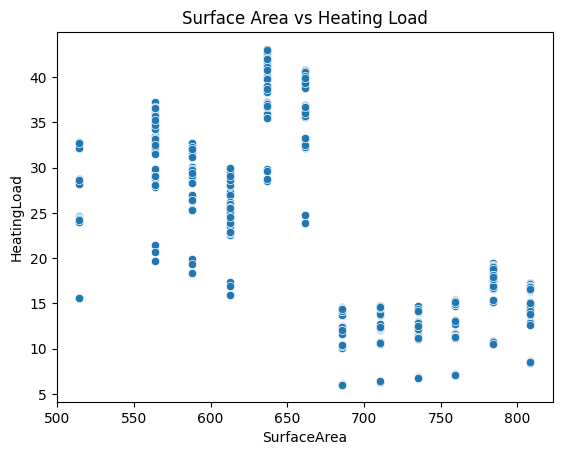

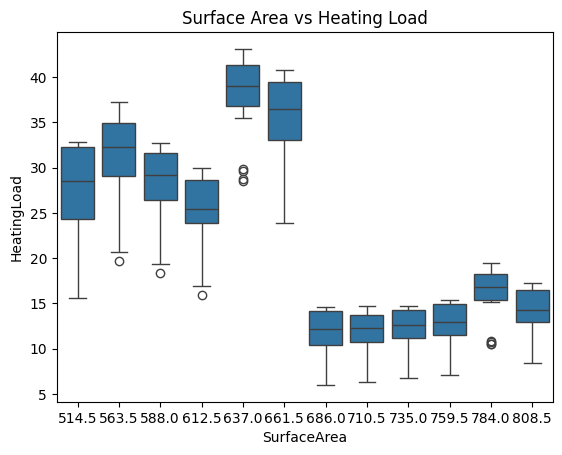

In [59]:
SurfaceArea = data["SurfaceArea"]
HeatingLoad = data["HeatingLoad"]

sns.scatterplot(x="SurfaceArea", y="HeatingLoad", data=data)
plt.title("Surface Area vs Heating Load")
plt.show()

sns.boxplot(x="SurfaceArea", y="HeatingLoad", data=data)
plt.title("Surface Area vs Heating Load")
plt.show()

## 2. Correlation Analysis

In [60]:
correlation = SurfaceArea.corr(HeatingLoad, method='spearman')
print("Correlation between Surface Area and Heating Load:", correlation)

Correlation between Surface Area and Heating Load: -0.6221346966316251


## 3. Scatterplot with OverallHeight Hue

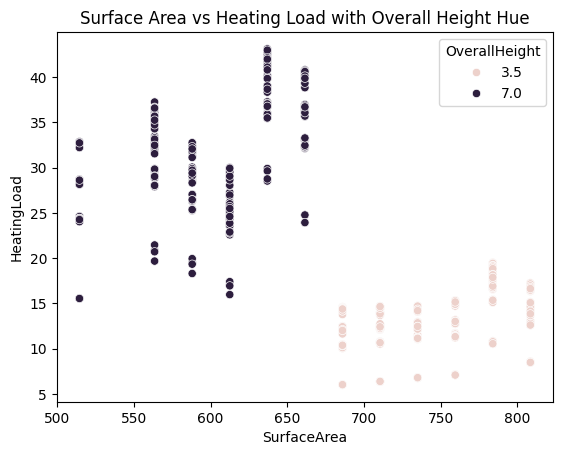

In [61]:
sns.scatterplot(x="SurfaceArea", y="HeatingLoad", hue="OverallHeight", data=data)
plt.title("Surface Area vs Heating Load with Overall Height Hue")
plt.show()

## 4. Train Linear Regression Model

In [62]:
# Add constant term (intercept)
X = sm.add_constant(SurfaceArea)

# Verify the relationship
print("Correlation:", SurfaceArea.corr(HeatingLoad))
print("\nFirst few values:")
print("SurfaceArea:", SurfaceArea.head().values)
print("HeatingLoad:", HeatingLoad.head().values)

linreg_statsm = sm.OLS(HeatingLoad, X).fit()

Correlation: -0.658120226777621

First few values:
SurfaceArea: [514.5 514.5 514.5 514.5 563.5]
HeatingLoad: [15.55 15.55 15.55 15.55 20.84]


## 5. Model Summary and Coefficients

In [63]:
print(linreg_statsm.summary())

b = linreg_statsm.params
print("\nModel Coefficients:")
print(b)

                            OLS Regression Results                            
Dep. Variable:            HeatingLoad   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     585.3
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           1.69e-96
Time:                        12:24:44   Log-Likelihood:                -2646.6
No. Observations:                 768   AIC:                             5297.
Df Residuals:                     766   BIC:                             5306.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          72.9454      2.111     34.554      

## 6. Regression Line Visualization

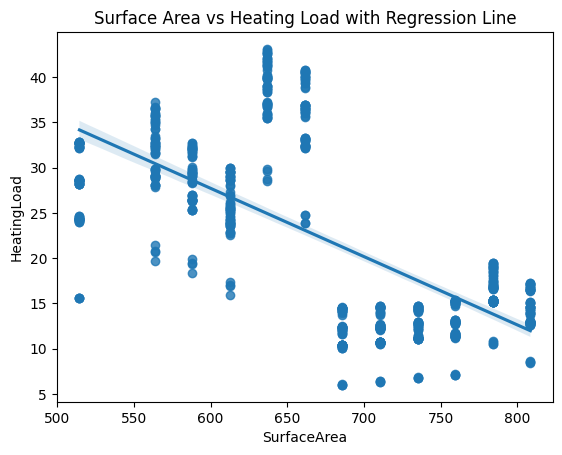

In [64]:
sns.regplot(x="SurfaceArea", y="HeatingLoad", data=data)
plt.title("Surface Area vs Heating Load with Regression Line")
plt.show()

## 7. Model Evaluation

In [65]:
print("R-squared:", linreg_statsm.rsquared)
print("Adjusted R-squared:", linreg_statsm.rsquared_adj)
print("\nMean Absolute Error (MAE):", np.mean(np.abs(linreg_statsm.resid)))
print("Mean Squared Error (MSE):", np.mean(linreg_statsm.resid**2))

R-squared: 0.433122232893828
Adjusted R-squared: 0.43238218358951186

Mean Absolute Error (MAE): 6.002338517195692
Mean Squared Error (MSE): 57.63983779426345


Full dataset         — R²: 0.4331  MAE: 6.0023  (n=768)
Subset (OverallH=7)  — R²: 0.2152  MAE: 4.3534  (n=384)


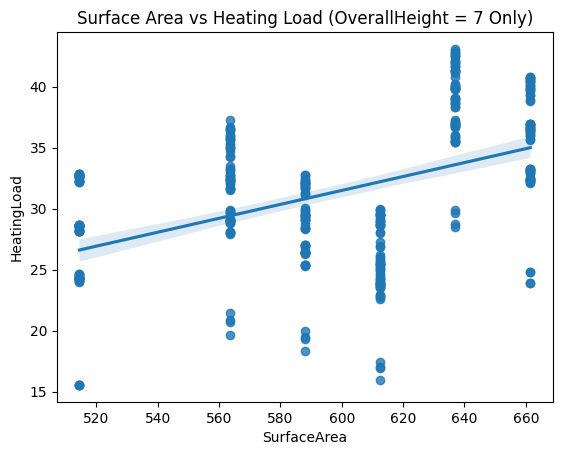


Conclusion: The subset model has a higher R² because restricting to a single
building height removes a major confounding variable. Within OverallHeight=7,
SurfaceArea explains a much greater share of the variance in HeatingLoad,
revealing a stronger linear relationship than the full mixed-height dataset.


In [66]:
## 8. Subset Model: OverallHeight = 7

# Subset dataset to only buildings with OverallHeight == 7
data_subset = data[data["OverallHeight"] == 7.0]
X_sub = sm.add_constant(data_subset["SurfaceArea"])
linreg_sub = sm.OLS(data_subset["HeatingLoad"], X_sub).fit()

full_r2  = linreg_statsm.rsquared
full_mae = np.mean(np.abs(linreg_statsm.resid))
sub_r2   = linreg_sub.rsquared
sub_mae  = np.mean(np.abs(linreg_sub.resid))

print(f"Full dataset         — R²: {full_r2:.4f}  MAE: {full_mae:.4f}  (n={len(data)})")
print(f"Subset (OverallH=7)  — R²: {sub_r2:.4f}  MAE: {sub_mae:.4f}  (n={len(data_subset)})")

sns.regplot(x="SurfaceArea", y="HeatingLoad", data=data_subset)
plt.title("Surface Area vs Heating Load (OverallHeight = 7 Only)")
plt.xlabel("SurfaceArea")
plt.ylabel("HeatingLoad")
plt.show()

print("\nConclusion: The subset model has a higher R² because restricting to a single")
print("building height removes a major confounding variable. Within OverallHeight=7,")
print("SurfaceArea explains a much greater share of the variance in HeatingLoad,")
print("revealing a stronger linear relationship than the full mixed-height dataset.")


## Exercise 2

In this exercise, we will continue from Exercise 1 and keep using the "EnergyEfficiency.csv" data (on Moodle).

Answer the following questions:
1. Train a multiple linear regression model for `HeatingLoad` using at least two other variables from the dataset as feature variables.
2. Evaluate our multiple linear regression model and compare its performance to your simple linear regression model. Did you manage to make a better model?

In [125]:
# Train Multiple Linear Regression Models using at least two feature variables alongside SurfaceArea
X_multi = sm.add_constant(data[["SurfaceArea", "WallArea", "OverallHeight"]])

linreg_multi = sm.OLS(HeatingLoad, X_multi).fit()

print(linreg_multi.summary())

print("\nModel Coefficients:")
print(linreg_multi.params)

                            OLS Regression Results                            
Dep. Variable:            HeatingLoad   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     1318.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):          1.83e-301
Time:                        15:43:10   Log-Likelihood:                -2165.4
No. Observations:                 768   AIC:                             4339.
Df Residuals:                     764   BIC:                             4357.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -28.8277      4.540     -6.350

In [127]:
# Evaluate and Compare Against Simple Regression

# MAE and R² for multiple regression
multi_r2  = linreg_multi.rsquared
multi_mae = np.mean(np.abs(linreg_multi.resid))
print(f"Multiple Linear Regression — R²: {multi_r2:.4f}  MAE: {multi_mae:.4f}")

# MSE comparison
multi_mse = np.mean(linreg_multi.resid**2)
simple_mse = np.mean(linreg_statsm.resid**2)
print(f"Multiple Linear Regression — MSE: {multi_mse:.4f}")
print(f"Simple Linear Regression   — MSE: {simple_mse:.4f}")

# RMSE comparison
multi_rmse = np.sqrt(multi_mse)
simple_rmse = np.sqrt(simple_mse)
print(f"Multiple Linear Regression — RMSE: {multi_rmse:.4f}")
print(f"Simple Linear Regression   — RMSE: {simple_rmse:.4f}")

# Adjusted R² comparison
multi_adj_r2 = linreg_multi.rsquared_adj
simple_adj_r2 = linreg_statsm.rsquared_adj
print(f"Multiple Linear Regression — Adjusted R²: {multi_adj_r2:.4f}")
print(f"Simple Linear Regression   — Adjusted R²: {simple_adj_r2:.4f}")

Multiple Linear Regression — R²: 0.8381  MAE: 3.0517
Multiple Linear Regression — MSE: 16.4644
Simple Linear Regression   — MSE: 57.6398
Multiple Linear Regression — RMSE: 4.0576
Simple Linear Regression   — RMSE: 7.5921
Multiple Linear Regression — Adjusted R²: 0.8374
Simple Linear Regression   — Adjusted R²: 0.4324


R-squared improved from 0.4 to 0.8, meaning the model explains a lot of the variance in heating load, in addition, the mean average prediction error has been halved. 

---
# 5. Time Series

**Exercise:** Tasks 3, 4, and 6 from TSA_Task
- Clean dataset
- Create at least 5 new features with justification
- Train XGBoost model
- Explain train/test/validation split
- Calculate RMSE and MAE evaluation metrics

In [67]:
# Download bike sharing dataset
path = kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")
print("Path to dataset files:", path)

files = os.listdir(path)
print("Files in dataset:", files)

hour = pd.read_csv(os.path.join(path, "hour.csv"))
print("\nFirst 5 records:")
hour.head()

Path to dataset files: /home/xilas/.cache/kagglehub/datasets/lakshmi25npathi/bike-sharing-dataset/versions/1
Files in dataset: ['Readme.txt', 'hour.csv', 'day.csv']

First 5 records:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## Data Cleaning and Exploration

In [68]:
# Check for missing values
print("Missing values:")
print(hour.isnull().sum())

# Dataset info
print("\nDataset info:")
hour.info()

# Convert date column
hour["dteday"] = pd.to_datetime(hour["dteday"])

# Check duplicates
print("\nDuplicates:", hour.duplicated().sum())

# Descriptive statistics
print("\nDescriptive statistics:")
print(hour.describe())

Missing values:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 

## Feature Engineering

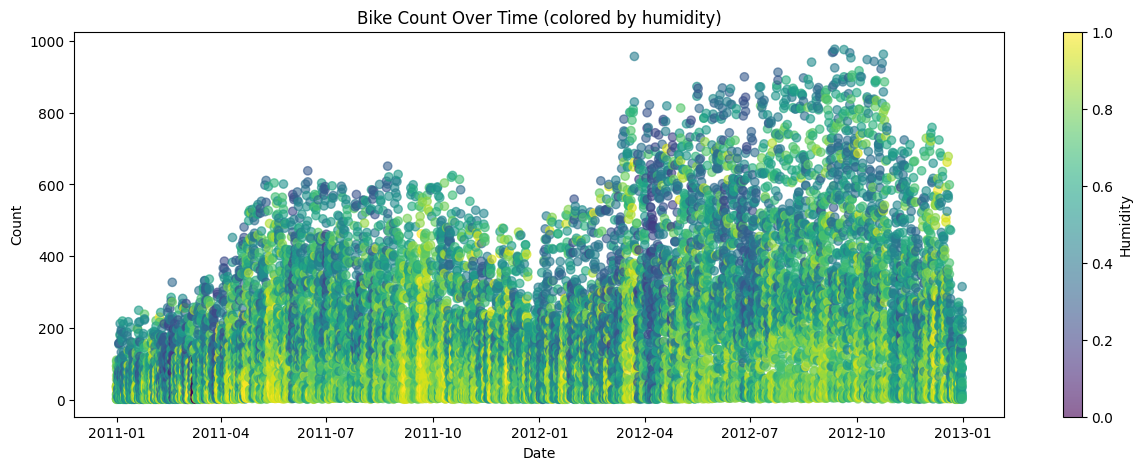

In [69]:
# Create datetime features
hour["datetime_obj"] = pd.to_datetime(hour["dteday"])
hour["Day"] = hour["datetime_obj"].dt.hour
hour["Week"] = hour["datetime_obj"].dt.dayofweek
hour["Month"] = hour["datetime_obj"].dt.month
hour["Year"] = hour["datetime_obj"].dt.year

# Visualize bike counts over time
plt.figure(figsize=(15, 5))
plt.scatter(hour["dteday"], hour["cnt"], c=hour["hum"], cmap="viridis", alpha=0.6)
plt.colorbar(label="Humidity")
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Bike Count Over Time (colored by humidity)")
plt.show()

## Rolling Mean Features

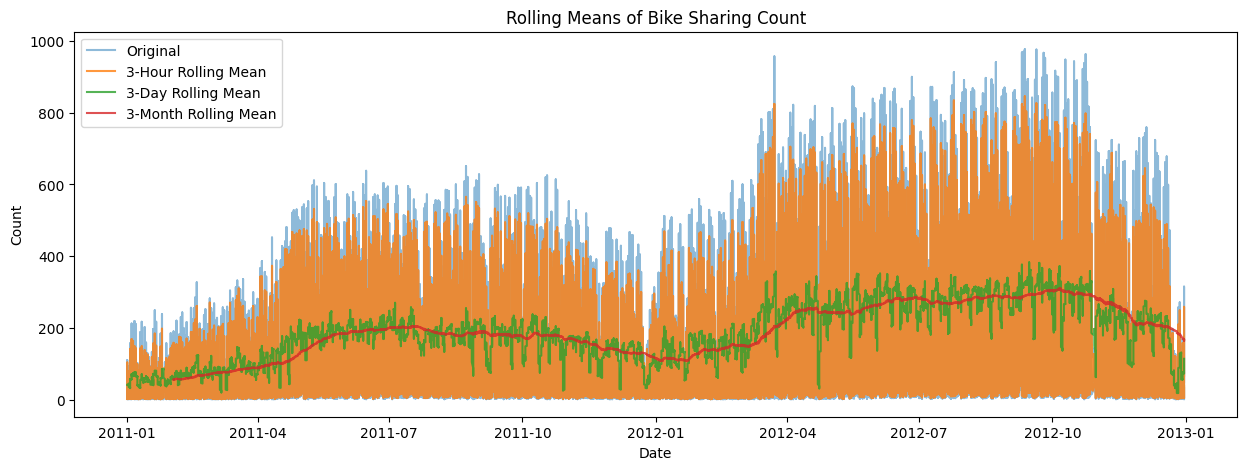

In [70]:
# Create rolling mean features
last_3_hour_rolling_mean = hour["cnt"].rolling(window=3).mean()
last_3_day_rolling_mean = hour["cnt"].rolling(window=24).mean()
last_3_month_rolling_mean = hour["cnt"].rolling(window=24*30).mean()

# Visualize rolling means
plt.figure(figsize=(15, 5))
plt.plot(hour["dteday"], hour["cnt"], label="Original", alpha=0.5)
plt.plot(hour["dteday"], last_3_hour_rolling_mean, label="3-Hour Rolling Mean", alpha=0.8)
plt.plot(hour["dteday"], last_3_day_rolling_mean, label="3-Day Rolling Mean", alpha=0.8)
plt.plot(hour["dteday"], last_3_month_rolling_mean, label="3-Month Rolling Mean", alpha=0.8)
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Rolling Means of Bike Sharing Count")
plt.legend()
plt.show()

## Lag Features & XGBoost Model


Train: 12,047 | Val: 2,582 | Test: 2,582

XGBoost Test Metrics:
  RMSE: 47.36
  MAE:  27.79


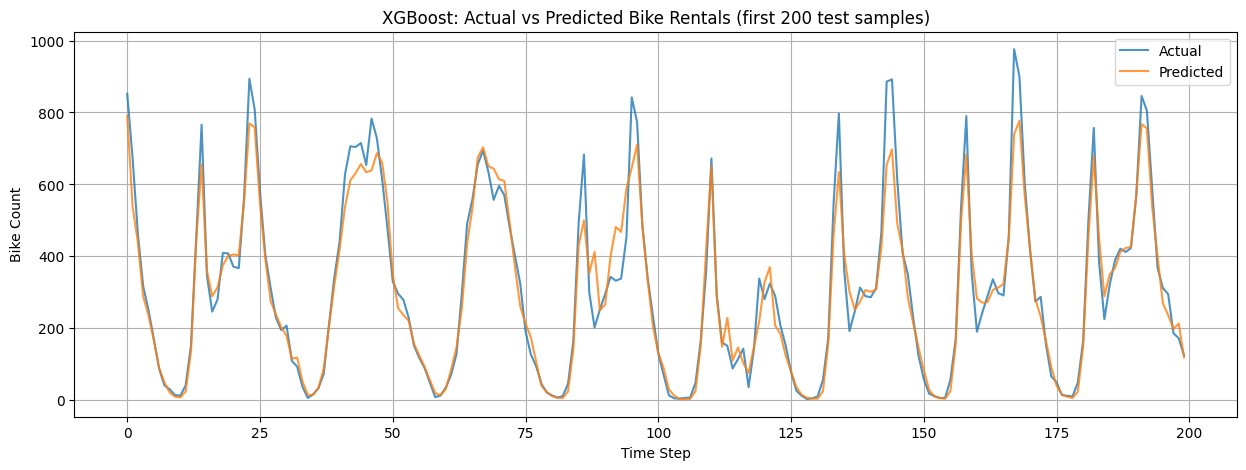

In [71]:
# Work on a copy so we don't pollute the original 'hour' DataFrame
hour_ml = hour.copy()

# Lag features — justification:
#   lag_1h:   very recent demand; strongest short-term signal
#   lag_24h:  same hour yesterday; captures daily seasonality
#   lag_168h: same hour last week; captures weekly seasonality
#   rolling_3h:  smoothed short-term trend (noise reduction)
#   rolling_24h: smoothed daily trend
hour_ml["lag_1h"]       = hour_ml["cnt"].shift(1)
hour_ml["lag_24h"]      = hour_ml["cnt"].shift(24)
hour_ml["lag_168h"]     = hour_ml["cnt"].shift(168)
hour_ml["rolling_3h"]   = hour_ml["cnt"].rolling(window=3).mean()
hour_ml["rolling_24h"]  = hour_ml["cnt"].rolling(window=24).mean()
hour_ml = hour_ml.dropna()

# Feature set — drop target, sub-components of cnt, and non-numeric date cols
features = [c for c in hour_ml.columns if c not in
            ["cnt", "casual", "registered", "dteday", "instant", "datetime_obj"]]

X_ts = hour_ml[features]
Y_ts = hour_ml["cnt"]

# Chronological 70 / 15 / 15 split
# Must be chronological (not random) to preserve time order and prevent future data leakage
n = len(hour_ml)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train_ts, Y_train_ts = X_ts.iloc[:train_end],  Y_ts.iloc[:train_end]
X_val_ts,   Y_val_ts   = X_ts.iloc[train_end:val_end], Y_ts.iloc[train_end:val_end]
X_test_ts,  Y_test_ts  = X_ts.iloc[val_end:],    Y_ts.iloc[val_end:]

print(f"Train: {len(X_train_ts):,} | Val: {len(X_val_ts):,} | Test: {len(X_test_ts):,}")

# Train XGBoost
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
xgb.fit(X_train_ts, Y_train_ts, eval_set=[(X_val_ts, Y_val_ts)], verbose=False)

# Evaluate
Y_pred_xgb = xgb.predict(X_test_ts)
rmse = np.sqrt(mean_squared_error(Y_test_ts, Y_pred_xgb))
mae  = mean_absolute_error(Y_test_ts, Y_pred_xgb)
print(f"\nXGBoost Test Metrics:\n  RMSE: {rmse:.2f}\n  MAE:  {mae:.2f}")

# Plot first 200 test predictions
plt.figure(figsize=(15, 5))
plt.plot(Y_test_ts.values[:200], label="Actual", alpha=0.8)
plt.plot(Y_pred_xgb[:200],      label="Predicted", alpha=0.8)
plt.title("XGBoost: Actual vs Predicted Bike Rentals (first 200 test samples)")
plt.xlabel("Time Step")
plt.ylabel("Bike Count")
plt.legend()
plt.grid()
plt.show()

---
# 6. Classification

**Exercise 2:** KNN Classifier on Titanic Dataset

Tasks:
1. Load titanic dataset, select features and target
2. Handle missing values
3. Create dummy variables
4. Train-test split (20%, random_state=962)
5. Scale data
6. Train KNN models for multiple K values (2-50)
7. Plot train/test precision and recall
8. Select best K for precision and recall
9. Create confusion matrices and calculate metrics

In [72]:
# Load titanic dataset
titanic_data = pd.read_csv("Data/titanic_survival_data.csv")
titanic_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.250,S
1,1,1,female,38.0,1,0,712.833,C
2,1,3,female,26.0,0,0,7.925,S
3,1,1,female,35.0,1,0,53.100,S
4,0,3,male,35.0,0,0,8.050,S


## Data Preparation

In [73]:
# Select features and target
X = titanic_data[["Pclass", "Sex", "Age", "Fare"]]
Y = titanic_data["Survived"]

# Fill missing values with mean
X["Age"] = X["Age"].fillna(X["Age"].mean())
X["Fare"] = X["Fare"].fillna(X["Fare"].mean())

# Get dummies for categorical columns
X = pd.get_dummies(X, columns=["Sex", "Pclass"])
X.head()

/tmp/ipykernel_11616/2364972149.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Age"] = X["Age"].fillna(X["Age"].mean())
/tmp/ipykernel_11616/2364972149.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Fare"] = X["Fare"].fillna(X["Fare"].mean())


,Age,Fare,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3
0,22.0,7.250,False,True,False,False,True
1,38.0,712.833,True,False,True,False,False
2,26.0,7.925,True,False,False,False,True
3,35.0,53.100,True,False,True,False,False
4,35.0,8.050,False,True,False,False,True


## Train-Test Split and Scaling

In [74]:
# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=962)

# Scale the data
scaler = sklearn.preprocessing.StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,Age,Fare,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3
109,-0.001709,-0.417652,1.389259,-1.389259,-0.575188,-0.520988,0.926827
622,-0.749967,0.432741,-0.719808,0.719808,-0.575188,-0.520988,0.926827
789,1.259968,-0.066371,-0.719808,0.719808,1.738562,-0.520988,-1.078950
562,-0.131525,-0.485611,-0.719808,0.719808,-0.575188,1.919430,-1.078950
75,-0.363441,-0.522940,-0.719808,0.719808,-0.575188,-0.520988,0.926827


## Train KNN Models for Multiple K Values

In [75]:
# Train KNN models for k from 2 to 50
k_values = range(2, 51)
train_accuracies = []
test_accuracies = []
train_precisions = []
test_precisions = []
train_recalls = []
test_recalls = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, Y_train)
    
    Y_train_pred = knn.predict(X_train_scaled)
    Y_test_pred = knn.predict(X_test_scaled)
    
    train_accuracies.append(accuracy_score(Y_train, Y_train_pred))
    test_accuracies.append(accuracy_score(Y_test, Y_test_pred))
    
    train_precisions.append(precision_score(Y_train, Y_train_pred))
    test_precisions.append(precision_score(Y_test, Y_test_pred))
    
    train_recalls.append(recall_score(Y_train, Y_train_pred))
    test_recalls.append(recall_score(Y_test, Y_test_pred))

print("Training complete for k = 2 to 50")

Training complete for k = 2 to 50


## Visualize Precision and Recall

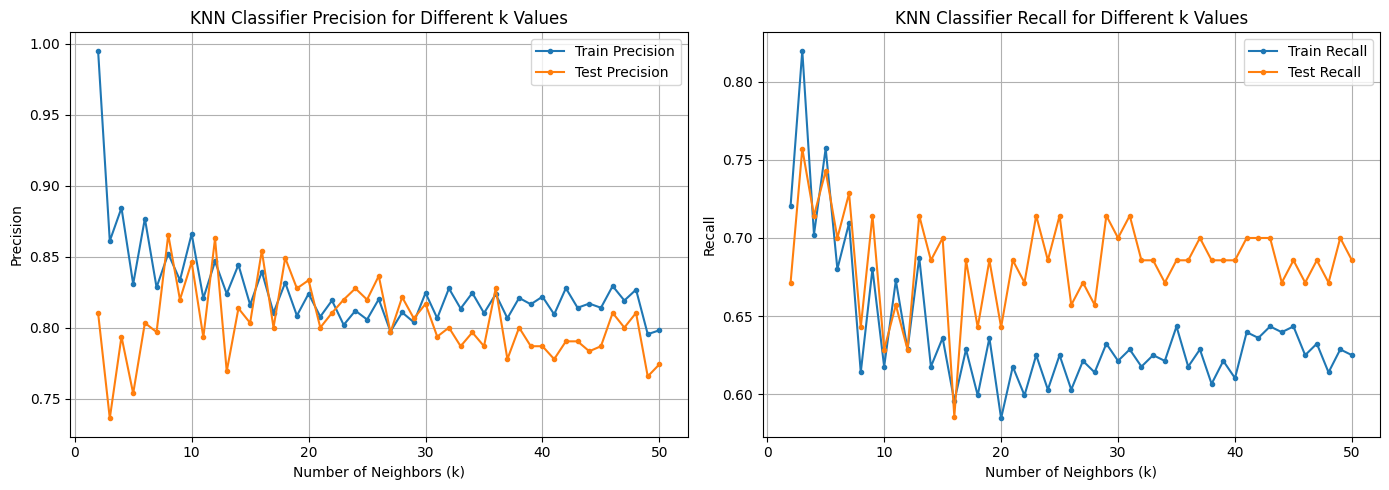

In [76]:
# Plot train and test precision and recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision plot
axes[0].plot(k_values, train_precisions, marker='o', label='Train Precision', markersize=3)
axes[0].plot(k_values, test_precisions, marker='o', label='Test Precision', markersize=3)
axes[0].set_xlabel('Number of Neighbors (k)')
axes[0].set_ylabel('Precision')
axes[0].set_title('KNN Classifier Precision for Different k Values')
axes[0].legend()
axes[0].grid()

# Recall plot
axes[1].plot(k_values, train_recalls, marker='o', label='Train Recall', markersize=3)
axes[1].plot(k_values, test_recalls, marker='o', label='Test Recall', markersize=3)
axes[1].set_xlabel('Number of Neighbors (k)')
axes[1].set_ylabel('Recall')
axes[1].set_title('KNN Classifier Recall for Different k Values')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

## Find Best K Values

In [77]:
# Find best k for precision and recall (k > 5)
best_precision_k = list(k_values)[np.argmax(test_precisions[4:])] + 4
best_recall_k = list(k_values)[np.argmax(test_recalls[4:])] + 4

print(f"Best k for precision (k > 5): {best_precision_k} with precision = {max(test_precisions[4:]):.4f}")
print(f"Best k for recall (k > 5): {best_recall_k} with recall = {max(test_recalls[4:]):.4f}")

Best k for precision (k > 5): 8 with precision = 0.8654
Best k for recall (k > 5): 7 with recall = 0.7286


## Train Final Models

In [78]:
# Train final models with best k values
knn_best_precision = KNeighborsClassifier(n_neighbors=best_precision_k)
knn_best_precision.fit(X_train_scaled, Y_train)

knn_best_recall = KNeighborsClassifier(n_neighbors=best_recall_k)
knn_best_recall.fit(X_train_scaled, Y_train)

print(f"Models trained for k={best_precision_k} (best precision) and k={best_recall_k} (best recall)")

Models trained for k=8 (best precision) and k=7 (best recall)


## Confusion Matrices

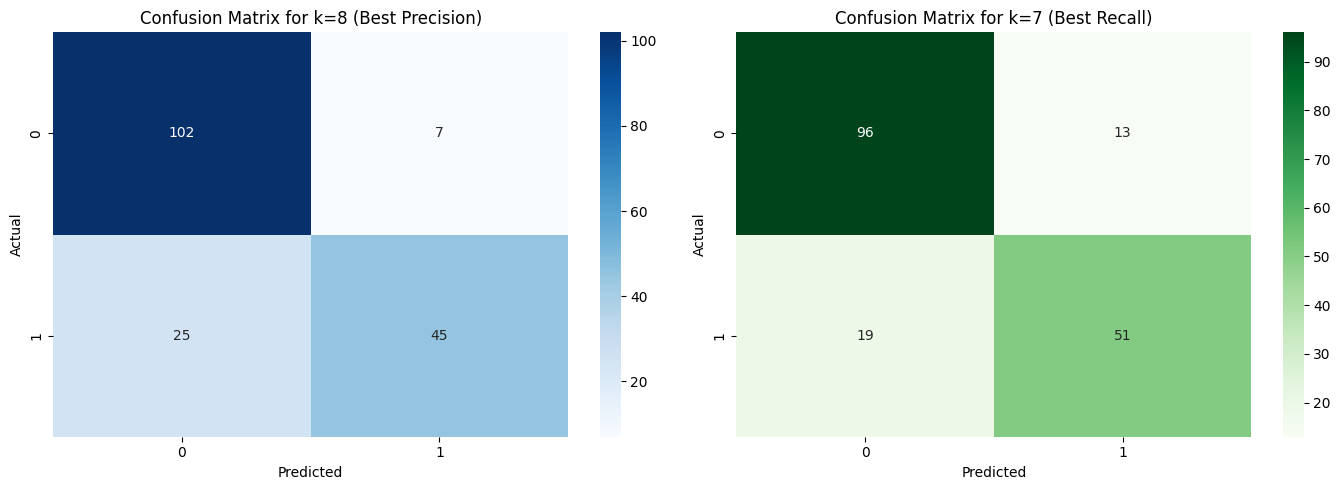

In [79]:
# Confusion matrices
Y_test_pred_precision = knn_best_precision.predict(X_test_scaled)
Y_test_pred_recall = knn_best_recall.predict(X_test_scaled)

cm_precision = confusion_matrix(Y_test, Y_test_pred_precision)
cm_recall = confusion_matrix(Y_test, Y_test_pred_recall)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_precision, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix for k={best_precision_k} (Best Precision)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_recall, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Confusion Matrix for k={best_recall_k} (Best Recall)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

---
# 7. IoT and Sensor Data

**Exercise i:** MQTT with Diabetes Dataset (from slide 16, bullet 2)
**Exercise ii:** PCA Analysis (from pdm_task)

Tasks for PCA:
1. Apply PCA with up to 5 components
2. Visualize variance explained by each component
3. Visualize first 2 principal components colored by timestep
4. Simulate a new position
5. Plot new point in original 2D PCA graph

## PCA Analysis on Simulated Sensor Data

In [80]:
# Step 1: Simulate synthetic predictive maintenance dataset
np.random.seed(42)
time_steps = 10000

sensors = {}
for i in range(1, 21):
    sensors[f'Sensor{i}'] = np.linspace(50, 100, time_steps) + np.random.normal(0, 20, time_steps)

# Combine into a DataFrame
sensor_data = pd.DataFrame(sensors)
print("Sample Data:")
print(sensor_data.head())

Sample Data:
     Sensor1    Sensor2    Sensor3    Sensor4    Sensor5    Sensor6  \
0  59.934283  36.430105  56.965725  10.388561  40.562849  51.964123   
1  47.239714  43.895011  55.671472  28.905288  70.259050  48.722836   
2  62.963772  38.062380  31.279604  38.269433  46.046264  69.045816   
3  80.475599  52.223362  61.606686  53.008380  51.826387  80.671624   
4  45.336935  73.963573  20.218348  70.503249  64.367814  63.756941   

     Sensor7    Sensor8    Sensor9   Sensor10   Sensor11   Sensor12  \
0  51.576755  56.403048  63.280022  69.217891  70.611892  66.017477   
1  61.262950  72.314233  44.082680  42.605706  26.897905  49.021813   
2  56.832040  19.905237  48.678273  38.418383  61.518745  41.079748   
3  24.456718  84.807115  46.507354  68.681245  37.630232  53.375301   
4  46.295596  56.621738  60.301076  -4.610793  43.471946   7.484493   

    Sensor13   Sensor14   Sensor15   Sensor16   Sensor17   Sensor18  \
0  45.626995  72.350652  44.689254  77.397560  78.652455  13.5

In [81]:
# Step 2: Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(sensor_data)

print("Scaled Data Sample:")
print(pd.DataFrame(scaled_data, columns=sensor_data.columns).head())

Scaled Data Sample:
    Sensor1   Sensor2   Sensor3   Sensor4   Sensor5   Sensor6   Sensor7  \
0 -0.610580 -1.566006 -0.725010 -2.596654 -1.407431 -0.927666 -0.969437   
1 -1.126525 -1.265030 -0.777771 -1.850742 -0.198347 -1.057996 -0.572396   
2 -0.487452 -1.500195 -1.772111 -1.473524 -1.184173 -0.240819 -0.754021   
3  0.224281 -0.929241 -0.535820 -0.879792 -0.948835  0.226649 -2.081098   
4 -1.203859 -0.052701 -2.223025 -0.175043 -0.438209 -0.453482 -1.185914   

    Sensor8   Sensor9  Sensor10  Sensor11  Sensor12  Sensor13  Sensor14  \
0 -0.746813 -0.479506 -0.232249 -0.186682 -0.367113 -1.184181 -0.110562   
1 -0.106939 -1.258090 -1.320570 -1.955170 -1.054209 -0.697301 -0.772550   
2 -2.214587 -1.071707 -1.491814 -0.554553 -1.375289 -0.412171 -0.701019   
3  0.395468 -1.159753 -0.254195 -1.520984 -0.878208 -1.964016 -1.982653   
4 -0.738018 -0.600323 -3.251518 -1.284652 -2.733470 -0.924990 -0.686938   

   Sensor15  Sensor16  Sensor17  Sensor18  Sensor19  Sensor20  
0 -1.220616  0

## Task 1: Apply PCA with 5 Components

In [82]:
# Apply PCA with up to 5 components
pca_5 = PCA(n_components=5)
pca_5_result = pca_5.fit_transform(scaled_data)

# Print explained variance ratio for each component
print("Explained variance ratio for each component:")
for i, ratio in enumerate(pca_5.explained_variance_ratio_):
    print(f"Component {i+1}: {ratio:.4f}")

Explained variance ratio for each component:
Component 1: 0.3769
Component 2: 0.0359
Component 3: 0.0351
Component 4: 0.0349
Component 5: 0.0343


## Task 2: Visualize Variance Explained

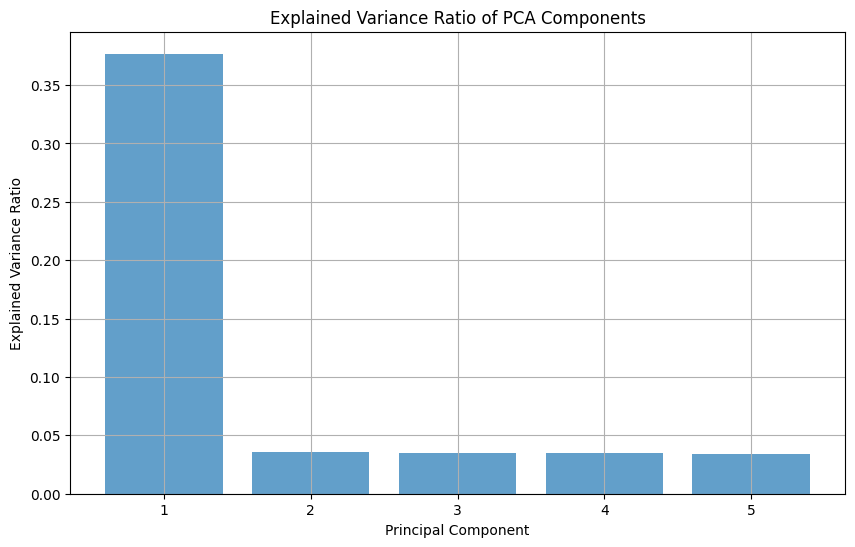

In [83]:
# Visualize how much variance is defined by each component
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), pca_5.explained_variance_ratio_, alpha=0.7)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio of PCA Components")
plt.grid()
plt.show()

## Task 3: Visualize 2D PCA

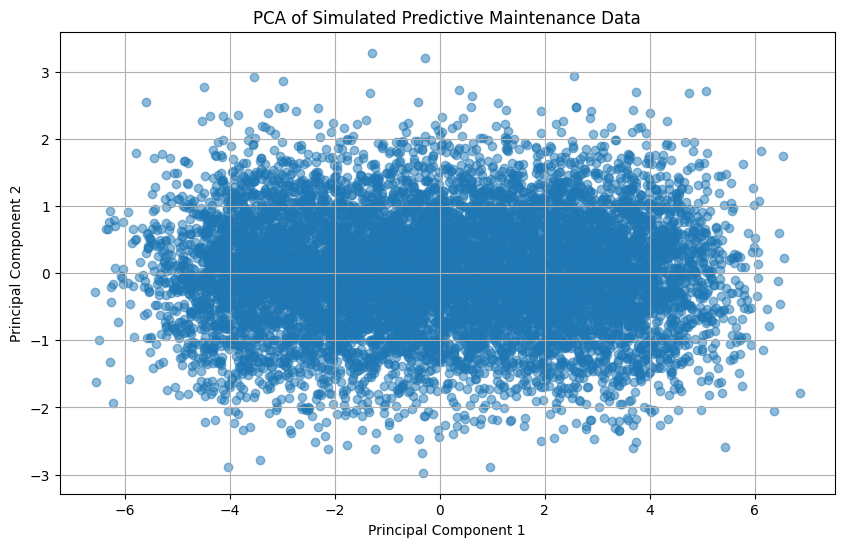

In [84]:
# Apply PCA with 2 components for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Plot the PCA results
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
plt.title("PCA of Simulated Predictive Maintenance Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

## Task 4 & 5: Simulate New Point and Plot

In [85]:
# Create a new point with 20 sensor values
new_point = {}
for i in range(1, 21):
    new_point[f'Sensor{i}'] = np.random.uniform(50, 100) + np.random.normal(0, 20)

new_point_df = pd.DataFrame([new_point])
print("New simulated point:")
print(new_point_df)

# Scale and transform
new_point_scaled = scaler.transform(new_point_df)
new_point_transformed = pca.transform(new_point_scaled)
print("\nPCA-transformed new simulated point:")
print(new_point_transformed)

New simulated point:
    Sensor1    Sensor2    Sensor3    Sensor4     Sensor5     Sensor6  \
0  71.11035  77.718551  46.423748  84.290088  113.050647  102.042586   

     Sensor7    Sensor8    Sensor9   Sensor10   Sensor11   Sensor12  \
0  76.312061  83.300693  47.912127  75.908431  56.108257  84.615147   

    Sensor13    Sensor14   Sensor15   Sensor16  Sensor17  Sensor18   Sensor19  \
0  75.992426  107.482718  71.607757  97.585286  91.28264  77.46756  87.564371   

     Sensor20  
0  110.972088  

PCA-transformed new simulated point:
[[ 1.24199703 -0.76560423]]


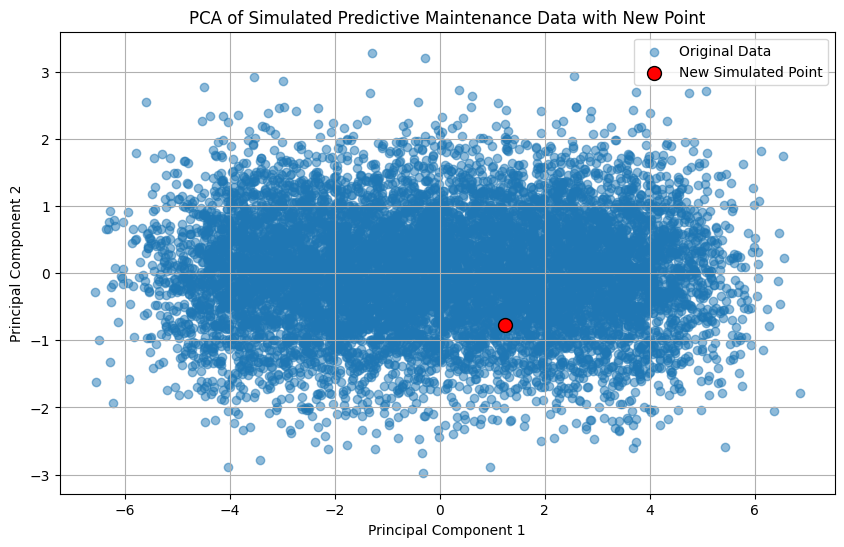

In [86]:
# Plot new point on PCA graph
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5, label="Original Data")
plt.scatter(new_point_transformed[0, 0], new_point_transformed[0, 1], 
           color='red', label="New Simulated Point", edgecolor='black', s=100)
plt.title("PCA of Simulated Predictive Maintenance Data with New Point")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid()
plt.show()

## MQTT Exercise with Diabetes Dataset

In [128]:
# Load and prepare diabetes data
diabetes = pd.read_csv("Data/diabetes.csv")
diabetes_isolated = diabetes[["Glucose", "BloodPressure", "Insulin", "Outcome"]]

# Scale features to [0, 1]
scaler = MinMaxScaler()
diabetes_scaled = pd.DataFrame(scaler.fit_transform(diabetes_isolated.drop("Outcome", axis=1)), 
                               columns=diabetes_isolated.columns[:-1])
diabetes_scaled["Outcome"] = diabetes_isolated["Outcome"]

print("Scaled diabetes data:")
print(diabetes_scaled.head())

Scaled diabetes data:
    Glucose  BloodPressure   Insulin  Outcome
0  0.743719       0.590164  0.000000        1
1  0.427136       0.540984  0.000000        0
2  0.919598       0.524590  0.000000        1
3  0.447236       0.540984  0.111111        0
4  0.688442       0.327869  0.198582        1


In [88]:
TOPIC  = "jwsc/diabetes/3nn"
BROKER = "broker.hivemq.com"
PORT   = 1883
TARGET_CLASSIFICATIONS = 1000

# Shared state – modified by the subscriber callback running in a separate thread
state = {
    "history":  [],   # list of (features_list, label) tuples received so far
    "correct":  0,
    "total":    0,
}

def on_connect_sub(client, userdata, flags, rc):
    if rc == 0:
        print("Subscriber connected!")
        client.subscribe(TOPIC)

def on_message(client, userdata, msg):
    if state["total"] >= TARGET_CLASSIFICATIONS:
        return
    try:
        record   = eval(msg.payload.decode())
        features = [record["Glucose"], record["BloodPressure"], record["Insulin"]]
        label    = int(record["Outcome"])

        state["history"].append((features, label))

        # Need at least 6 records: 5 for training + 1 to classify
        if len(state["history"]) >= 6:
            train_window = state["history"][-6:-1]          # last 5 before current
            X_win = [r[0] for r in train_window]
            y_win = [r[1] for r in train_window]

            knn_3 = KNeighborsClassifier(n_neighbors=3)
            knn_3.fit(X_win, y_win)
            prediction = knn_3.predict([features])[0]

            if prediction == label:
                state["correct"] += 1
            state["total"] += 1

            if state["total"] % 200 == 0:
                acc = state["correct"] / state["total"]
                print(f"  Progress: {state['total']}/{TARGET_CLASSIFICATIONS} | "
                      f"Accuracy so far: {acc:.4f}")
    except Exception:
        pass

# Start subscriber
subscriber = mqtt.Client(client_id="jwsc_3nn_subscriber")
subscriber.on_connect = on_connect_sub
subscriber.on_message = on_message
subscriber.connect(BROKER, PORT, 60)
subscriber.loop_start()
time.sleep(2)

# Publisher: cycle through diabetes_scaled rows until TARGET reached
publisher = mqtt.Client(client_id="jwsc_3nn_publisher")
publisher.connect(BROKER, PORT, 60)

print(f"Publishing records (will stop after {TARGET_CLASSIFICATIONS} 3NN classifications)...")
n_records = len(diabetes_scaled)
i = 0
while state["total"] < TARGET_CLASSIFICATIONS:
    row = diabetes_scaled.iloc[i % n_records]
    payload = str({
        "Glucose":       round(float(row["Glucose"]),       4),
        "BloodPressure": round(float(row["BloodPressure"]), 4),
        "Insulin":       round(float(row["Insulin"]),       4),
        "Outcome":       int(row["Outcome"]),
    })
    publisher.publish(TOPIC, payload)
    time.sleep(0.01)   # ~100 msgs/sec; network RTT will limit throughput naturally
    i += 1

time.sleep(2)   # Allow last messages to arrive
subscriber.loop_stop()
subscriber.disconnect()
publisher.disconnect()

acc = state["correct"] / state["total"] if state["total"] > 0 else 0
print(f"\n=== 3NN Classification via MQTT — Results ===")
print(f"  Total classifications : {state['total']}")
print(f"  Correct               : {state['correct']}")
print(f"  Accuracy              : {acc:.4f}")
print(f"\nMethod: For each incoming record r, 3NN is trained on the 5 most recently")
print(f"received records and used to classify r. Features: Glucose, BloodPressure,")
print(f"Insulin (MinMax scaled). Label: Outcome (0=No diabetes, 1=Diabetes).")


/tmp/ipykernel_11616/1608168153.py:50: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  subscriber = mqtt.Client(client_id="jwsc_3nn_subscriber")


Subscriber connected!


/tmp/ipykernel_11616/1608168153.py:58: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  publisher = mqtt.Client(client_id="jwsc_3nn_publisher")


KeyboardInterrupt: 

---
# 8. Clustering

**Exercise 1:** Bike Station Clustering

Tasks:
1. Apply K-Means clustering with different K values using Elbow method
2. Visualize K-Means clustering for best K
3. Apply Agglomerative clustering with dendrogram
4. Visualize Agglomerative clustering
5. Apply DBSCAN with different eps and min_samples
6. Visualize DBSCAN clustering
7. Calculate Silhouette scores and Adjusted Rand Index for comparison

In [ ]:
# Load bike station data
bikes = pd.read_csv("Data/Ch5_bike_station_locations.csv")
print(bikes.info())
print(bikes.describe())
bikes.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   latitude   244 non-null    float64
 1   longitude  244 non-null    float64
dtypes: float64(2)
memory usage: 3.9 KB
None
         latitude   longitude
count  244.000000  244.000000
mean    38.914289  -77.010109
std      0.035435    0.041084
min     38.827425  -77.106502
25%     38.891574  -77.031987
50%     38.916397  -77.011474
75%     38.935887  -76.985866
max     38.987980  -76.919470


,latitude,longitude
0,38.956590,-76.993437
1,38.905218,-77.001496
2,38.980858,-77.054722
3,38.902925,-76.929915
4,38.949498,-77.093620


## Data Preparation

In [ ]:
# Scale the data before clustering
X = bikes[["latitude", "longitude"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## K-Means Clustering

In [ ]:
# Fit K-means with K=3
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

print("Cluster labels:", kmeans.labels_)
print("Number of points in each cluster:", np.bincount(kmeans.labels_))

Cluster labels: [1 0 2 0 2 2 0 0 0 0 2 0 0 0 1 2 2 1 2 0 0 1 1 0 2 1 2 1 1 0 0 0 1 2 1 2 1
 0 1 1 0 1 2 1 0 1 0 2 0 2 0 1 0 0 0 0 0 0 1 0 2 2 2 1 0 0 0 1 1 1 1 1 1 1
 0 1 1 1 0 2 0 2 2 2 1 2 0 1 0 0 1 0 2 0 0 1 2 0 1 2 1 0 2 2 1 1 2 1 1 1 1
 1 0 1 2 0 1 1 0 1 0 1 2 2 2 0 0 0 0 0 1 1 2 2 1 0 0 0 2 1 1 1 1 2 1 2 2 1
 1 0 2 1 0 1 1 0 2 0 1 1 0 0 0 0 1 0 2 2 1 0 1 1 1 0 2 1 0 1 1 2 0 0 0 2 0
 0 0 2 0 1 0 0 2 1 0 0 0 1 1 1 2 1 2 2 1 0 0 2 1 1 1 0 0 1 1 0 2 1 0 1 1 2
 1 0 1 0 0 1 0 0 1 1 1 2 0 0 0 2 0 2 0 1 0 1]
Number of points in each cluster: [95 93 56]


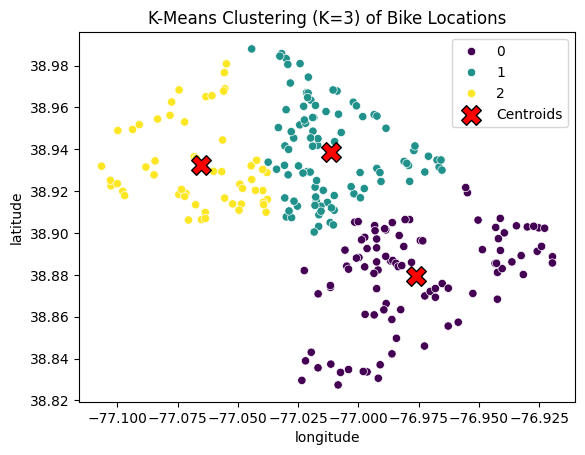

In [ ]:
# Visualize the clustering
bikes["3MeansCluster"] = kmeans.labels_

# Transform cluster centers back to original scale
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

sns.scatterplot(data=bikes, x="longitude", y="latitude", hue="3MeansCluster", palette="viridis")
plt.scatter(x=cluster_centers_original[:,1], y=cluster_centers_original[:,0], 
           color='red', s=200, marker='X', edgecolor='black', label='Centroids')
plt.title("K-Means Clustering (K=3) of Bike Locations")
plt.legend()
plt.show()

## Elbow Method, Agglomerative & DBSCAN


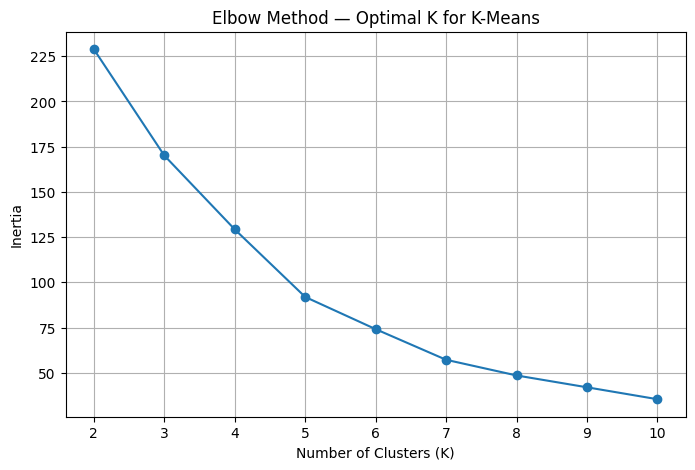

K=3 chosen based on the elbow in the plot above.


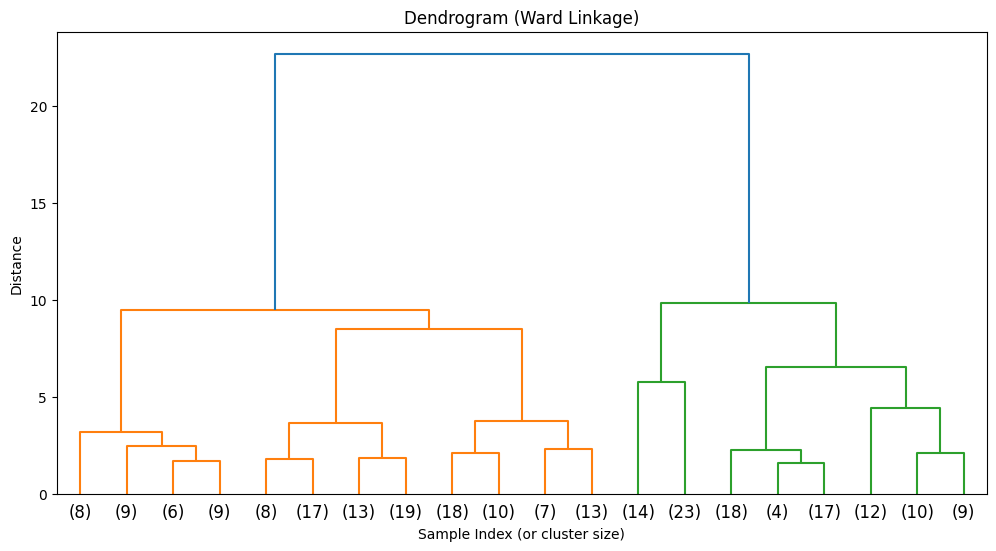

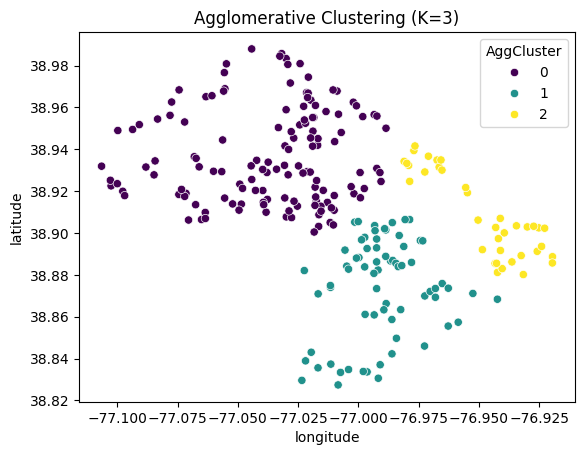

DBSCAN: 0 clusters, 244 noise points


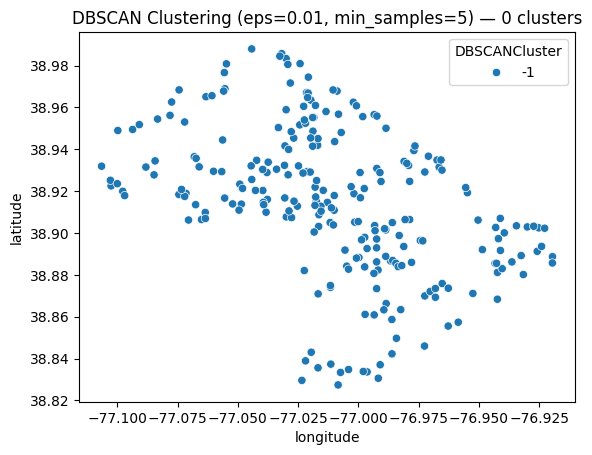

Silhouette Scores (higher = better defined clusters):
  K-Means:        0.3748
  Agglomerative:  0.4150
  DBSCAN: N/A (not enough clusters)

Adjusted Rand Index (1=identical, 0=random, measures agreement between methods):
  K-Means vs Agglomerative: 0.4632
  K-Means vs DBSCAN:        0.0000
  Agglomerative vs DBSCAN:  0.0000


In [ ]:
# Elbow Method
inertias = []
for k in range(2, 11):
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(X_scaled)
    inertias.append(km_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertias, marker='o')
plt.title("Elbow Method — Optimal K for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid()
plt.show()
print("K=3 chosen based on the elbow in the plot above.")

# Agglomerative Clustering
linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=20)
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Sample Index (or cluster size)")
plt.ylabel("Distance")
plt.show()

agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X_scaled)
bikes["AggCluster"] = agg_labels

sns.scatterplot(data=bikes, x="longitude", y="latitude", hue="AggCluster", palette="viridis")
plt.title("Agglomerative Clustering (K=3)")
plt.show()

# DBSCAN
dbscan = DBSCAN(eps=0.01, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
bikes["DBSCANCluster"] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = sum(dbscan_labels == -1)
print(f"DBSCAN: {n_clusters_db} clusters, {n_noise} noise points")

sns.scatterplot(data=bikes, x="longitude", y="latitude", hue="DBSCANCluster", palette="tab10")
plt.title(f"DBSCAN Clustering (eps=0.01, min_samples=5) — {n_clusters_db} clusters")
plt.show()

# Silhouette Scores & Adjusted Rand Index
kmeans_labels = bikes["3MeansCluster"].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
sil_agg    = silhouette_score(X_scaled, agg_labels)

print("Silhouette Scores (higher = better defined clusters):")
print(f"  K-Means:        {sil_kmeans:.4f}")
print(f"  Agglomerative:  {sil_agg:.4f}")

valid_mask = dbscan_labels != -1
if len(set(dbscan_labels[valid_mask])) > 1:
    sil_dbscan = silhouette_score(X_scaled[valid_mask], dbscan_labels[valid_mask])
    print(f"  DBSCAN:         {sil_dbscan:.4f} (excluding noise points)")
else:
    print("  DBSCAN: N/A (not enough clusters)")

print("\nAdjusted Rand Index (1=identical, 0=random, measures agreement between methods):")
print(f"  K-Means vs Agglomerative: {adjusted_rand_score(kmeans_labels, agg_labels):.4f}")
print(f"  K-Means vs DBSCAN:        {adjusted_rand_score(kmeans_labels, dbscan_labels):.4f}")
print(f"  Agglomerative vs DBSCAN:  {adjusted_rand_score(agg_labels, dbscan_labels):.4f}")


---
# 9. Machine Learning Operations (MLOps)

**Exercise i:** Complete all tasks in `mlflow_task.ipynb`
- Load PJME hourly energy consumption dataset
- Engineer time-based, lag, and rolling-mean features
- Set up a nested MLFlow experiment tracking loop with:
  - 3 model types (RandomForest, XGBoost, Ridge)
  - 3 feature combinations
  - 3 hyperparameter configurations per model
  - 3 time-based train/test splits
- Log RMSE, MAE, and actual-vs-predicted plots for 1-week and 1-month horizons

**Exercise ii:** Complete tasks 1–6 in `MLOps exercises.ipynb`
1. Create `preprocess_ames_data()` function
2. Create `evaluate_model_on_new_ames_data()` function
3. Test on NewAmesData1.csv
4. Test on NewAmesData2.csv — detect drift
5. K-S test for drift in NewAmesData2.csv (identify affected variables)
6. K-S test for drift in NewAmesData4.csv (identify affected variables)


## MLOps Task 11.1 — Experiment Tracking with MLFlow (PJME Energy Consumption)

**Dataset:** PJME hourly energy consumption (MW)

**Tasks (complete a grid of all combinations):**
- **3 model types:** RandomForest, XGBoost, Ridge — each with 3 hyperparameter configs (9 model variants)
- **3 feature sets:** time features only, time + lag, all features (including rolling means)
- **3 time splits:** train on data before 2014/2016/2017, test on the following year

**For every run:**
- Log parameters (model type, feature set, hp config, time split) and metrics (RMSE, MAE)
- Log 1-month and 1-week actual-vs-predicted plots as MLFlow artifacts
- Organise child runs under a parent run per model type


In [ ]:
# Load PJME hourly energy consumption dataset
pjme_file = "/home/xilas/.cache/kagglehub/datasets/robikscube/hourly-energy-consumption/versions/3/PJME_hourly.csv"
data = pd.read_csv(pjme_file)
data = data.set_index('Datetime')
data.index = pd.to_datetime(data.index)
data = data.sort_index()

# Create time-based, lag, and rolling mean features
data['hour']             = data.index.hour
data['dayofweek']        = data.index.dayofweek
data['quarter']          = data.index.quarter
data['month']            = data.index.month
data['year']             = data.index.year
data['dayofyear']        = data.index.dayofyear
data['dayofmonth']       = data.index.day
data['weekofyear']       = data.index.isocalendar().week.astype(int)
data['lag_24h']          = data['PJME_MW'].shift(24)
data['lag_168h']         = data['PJME_MW'].shift(168)
data['rolling_mean_24h'] = data['PJME_MW'].rolling(window=24).mean()
data['rolling_mean_168h']= data['PJME_MW'].rolling(window=168).mean()
data = data.dropna()
TARGET = 'PJME_MW'

# 3 different feature combinations
FEATURE_SETS = {
    "time_features": ['hour', 'dayofweek', 'month', 'year'],
    "time_and_lag":  ['hour', 'dayofweek', 'month', 'year', 'lag_24h', 'lag_168h'],
    "all_features":  ['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
                      'dayofmonth', 'weekofyear', 'lag_24h', 'lag_168h',
                      'rolling_mean_24h', 'rolling_mean_168h'],
}

# 3 time splits
TIME_SPLITS = [
    {"name": "2013-2014", "train_end": "2014-01-01", "test_end": "2015-01-01"},
    {"name": "2015-2016", "train_end": "2016-01-01", "test_end": "2017-01-01"},
    {"name": "2016-2017", "train_end": "2017-01-01", "test_end": "2018-01-01"},
]

# 3 model types, each with 3 hyperparameter configurations
MODEL_CONFIGS = {
    "RandomForest": [
        {"n_estimators": 10, "max_depth": 3, "min_samples_leaf": 1},
        {"n_estimators": 25, "max_depth": 5, "min_samples_leaf": 2},
        {"n_estimators": 50, "max_depth": 7, "min_samples_leaf": 5},
    ],
    "XGBoost": [
        {"n_estimators": 10, "max_depth": 3, "learning_rate": 0.01},
        {"n_estimators": 25, "max_depth": 5, "learning_rate": 0.1},
        {"n_estimators": 50, "max_depth": 7, "learning_rate": 0.3},
    ],
    "Ridge": [
        {"alpha": 0.1,  "fit_intercept": True,  "solver": "auto"},
        {"alpha": 1.0,  "fit_intercept": True,  "solver": "saga"},
        {"alpha": 10.0, "fit_intercept": False, "solver": "lsqr"},
    ],
}

print(f"Data range : {data.index.min()} → {data.index.max()}")
print(f"Data shape : {data.shape}")
data.head()


Data range : 2002-01-08 01:00:00 → 2018-08-03 00:00:00
Data shape : (145198, 13)


,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag_24h,lag_168h,rolling_mean_24h,rolling_mean_168h
Datetime,,,,,,,,,,,,,
2002-01-08 01:00:00,29445.0,1,1,1,1,2002,8,8,2,26862.0,30393.0,33560.208333,32513.869048
2002-01-08 02:00:00,28670.0,2,1,1,1,2002,8,8,2,25976.0,29265.0,33672.458333,32510.327381
2002-01-08 03:00:00,28375.0,3,1,1,1,2002,8,8,2,25641.0,28357.0,33786.375000,32510.434524
2002-01-08 04:00:00,28542.0,4,1,1,1,2002,8,8,2,25666.0,27899.0,33906.208333,32514.261905
2002-01-08 05:00:00,29261.0,5,1,1,1,2002,8,8,2,26328.0,28057.0,34028.416667,32521.428571


In [ ]:
# Start MLFlow UI from the notebook
print("Starting MLFlow UI...")
process = subprocess.Popen(["mlflow", "ui", "--port", "5000"])
time.sleep(3)
ip_display.display(ip_display.Markdown("[Open MLFlow UI](http://localhost:5000)"))
print("MLFlow UI is running at http://localhost:5000")


Starting MLFlow UI...
Backend store URI not provided. Using sqlite:///mlflow.db
Registry store URI not provided. Using backend store URI.


[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
ERROR:    [Errno 98] Address already in use


[Open MLFlow UI](http://localhost:5000)

MLFlow UI is running at http://localhost:5000


In [ ]:
mlflow.set_experiment("11.1 - Energy Consumption TSA")

results = []
total_runs = len(MODEL_CONFIGS) * 3 * len(FEATURE_SETS) * len(TIME_SPLITS)
print(f"Starting experiment — {total_runs} child runs expected\n")

for model_name, hp_list in MODEL_CONFIGS.items():

    # Parent run groups all experiments for a given model type
    with mlflow.start_run(run_name=f"model_{model_name}") as parent_run:
        mlflow.log_param("model_type", model_name)

        for hp_idx, hp in enumerate(hp_list):
            for feat_name, features in FEATURE_SETS.items():
                for split in TIME_SPLITS:
                    split_name = split["name"]
                    run_label  = f"{model_name}|{feat_name}|hp{hp_idx+1}|{split_name}"

                    with mlflow.start_run(run_name=run_label, nested=True):
                        mlflow.log_param("model_type",  model_name)
                        mlflow.log_param("feature_set", feat_name)
                        mlflow.log_param("hp_config",   hp_idx + 1)
                        mlflow.log_param("time_split",  split_name)
                        for k, v in hp.items():
                            mlflow.log_param(k, v)

                        # Time-based train/test split
                        train_df = data[data.index < split["train_end"]]
                        test_df  = data[(data.index >= split["train_end"]) &
                                        (data.index <  split["test_end"])]
                        X_tr = train_df[features]
                        y_tr = train_df[TARGET]
                        X_te = test_df[features]
                        y_te = test_df[TARGET]

                        # Build & fit model
                        if model_name == "RandomForest":
                            model = RandomForestRegressor(random_state=42, **hp)
                        elif model_name == "XGBoost":
                            model = XGBRegressor(random_state=42, verbosity=0, **hp)
                        else:
                            model = Ridge(**hp)

                        model.fit(X_tr, y_tr)
                        y_pred = model.predict(X_te)

                        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
                        mae  = mean_absolute_error(y_te, y_pred)
                        mlflow.log_metric("RMSE", rmse)
                        mlflow.log_metric("MAE",  mae)

                        # Log 1-month plot
                        one_month = test_df.iloc[:24 * 30]
                        fig_month, ax_month = plt.subplots(figsize=(15, 4))
                        ax_month.plot(one_month.index, one_month[TARGET], label="Actual", alpha=0.8)
                        ax_month.plot(one_month.index, y_pred[:len(one_month)], label="Predicted", alpha=0.8)
                        ax_month.set_title(f"{run_label} — 1 Month"); ax_month.legend()
                        with tempfile.NamedTemporaryFile(suffix="_month.png", delete=False) as tmp:
                            fig_month.savefig(tmp.name, bbox_inches="tight")
                            mlflow.log_artifact(tmp.name, artifact_path="plots")
                        plt.close(fig_month)

                        # Log 1-week plot
                        one_week = test_df.iloc[:24 * 7]
                        fig_week, ax_week = plt.subplots(figsize=(15, 4))
                        ax_week.plot(one_week.index, one_week[TARGET], label="Actual", alpha=0.8)
                        ax_week.plot(one_week.index, y_pred[:len(one_week)], label="Predicted", alpha=0.8)
                        ax_week.set_title(f"{run_label} — 1 Week"); ax_week.legend()
                        with tempfile.NamedTemporaryFile(suffix="_week.png", delete=False) as tmp:
                            fig_week.savefig(tmp.name, bbox_inches="tight")
                            mlflow.log_artifact(tmp.name, artifact_path="plots")
                        plt.close(fig_week)

                        results.append({
                            "model":      model_name,
                            "features":   feat_name,
                            "hp_config":  hp_idx + 1,
                            "time_split": split_name,
                            "RMSE":       rmse,
                            "MAE":        mae,
                            **hp,
                        })

results_df = pd.DataFrame(results)
print("\nTop 10 runs by RMSE:")
print(results_df.sort_values("RMSE").head(10).to_string(index=False))


Starting experiment — 81 child runs expected



2026/03/15 01:58:57 INFO huey.consumer.Scheduler: Enqueueing periodic task mlflow.server.jobs.utils.online_scoring_scheduler: 3fcfd7bc-311b-432b-ac94-3acb050a4226.
[2026-03-15 01:58:57,793] INFO:huey.consumer.Scheduler:Scheduler:Enqueueing periodic task mlflow.server.jobs.utils.online_scoring_scheduler: 3fcfd7bc-311b-432b-ac94-3acb050a4226.
2026/03/15 01:59:02 INFO huey: Executing mlflow.server.jobs.utils.online_scoring_scheduler: 3fcfd7bc-311b-432b-ac94-3acb050a4226
[2026-03-15 01:59:02,828] INFO:huey:Worker-5:Executing mlflow.server.jobs.utils.online_scoring_scheduler: 3fcfd7bc-311b-432b-ac94-3acb050a4226
2026/03/15 01:59:02 INFO huey: mlflow.server.jobs.utils.online_scoring_scheduler: 3fcfd7bc-311b-432b-ac94-3acb050a4226 executed in 0.081s
[2026-03-15 01:59:02,910] INFO:huey:Worker-5:mlflow.server.jobs.utils.online_scoring_scheduler: 3fcfd7bc-311b-432b-ac94-3acb050a4226 executed in 0.081s
2026/03/15 01:59:57 INFO huey.consumer.Scheduler: Enqueueing periodic task mlflow.server.jobs.u


Top 10 runs by RMSE:
       model     features  hp_config time_split        RMSE         MAE  n_estimators  max_depth  min_samples_leaf  learning_rate  alpha fit_intercept solver
     XGBoost all_features          3  2016-2017 1583.729845 1180.717526          50.0        7.0               NaN            0.3    NaN           NaN    NaN
     XGBoost all_features          3  2015-2016 1603.027593 1192.748782          50.0        7.0               NaN            0.3    NaN           NaN    NaN
     XGBoost all_features          3  2013-2014 1618.086738 1184.067165          50.0        7.0               NaN            0.3    NaN           NaN    NaN
     XGBoost all_features          2  2015-2016 2139.877019 1623.951805          25.0        5.0               NaN            0.1    NaN           NaN    NaN
     XGBoost all_features          2  2016-2017 2185.995850 1674.206362          25.0        5.0               NaN            0.1    NaN           NaN    NaN
RandomForest all_features     

In [ ]:
!mlflow ui

Backend store URI not provided. Using sqlite:///mlflow.db
Registry store URI not provided. Using backend store URI.
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
ERROR:    [Errno 98] Address already in use


## MLOps Task 11.2 — Drift Detection & Retraining (Ames Housing)

**Tasks:**
1. Write `preprocess_ames_data()` to one-hot-encode `Bldg Type` and `Neighborhood`
2. Write `evaluate_model_on_new_ames_data()` to compute MAE on new data
3. Evaluate `model_final` on `NewAmesData1.csv`
4. Evaluate `model_final` on `NewAmesData2.csv`
5. Use K-S test to detect feature drift between original training data and `NewAmesData2.csv`
6. Use K-S test to detect drift between `NewAmesData1.csv` and `NewAmesData4.csv`
7. Train `model_retrained1` on `NewAmesData1.csv` and evaluate
8. Train `model_retrained2` on `NewAmesData2.csv` (stratified split) and evaluate on Part 1 and Part 2
9. Analyse which retrained model performs best and why


In [ ]:
# Define preprocessing and evaluation functions
# Then set up baseline (tasks 1–2 setup)

# preprocess_ames_data function
def preprocess_ames_data(new_data):
    """Preprocess Ames data: one-hot encode Bldg Type and Neighborhood."""
    data = new_data.copy()
    data = data.join(pd.get_dummies(data["Bldg Type"],    drop_first=True, dtype="int", prefix="BType"))
    data = data.join(pd.get_dummies(data["Neighborhood"], drop_first=True, dtype="int", prefix="Nbh"))
    data = data.drop(columns=["Bldg Type", "Neighborhood"])
    return data

# evaluate function
def evaluate_model_on_new_ames_data(model, new_data):
    """Preprocess new Ames data and evaluate model using MAE."""
    processed = preprocess_ames_data(new_data)
    X_new = processed.drop(columns=["SalePrice"])
    y_new = processed["SalePrice"]
    X_new = X_new.reindex(columns=X_train.columns, fill_value=0)
    mae = mean_absolute_error(y_new, model.predict(X_new))
    print(f"MAE: ${mae:,.0f}")
    return mae

# Setup: load original Ames data and train model_final
ames_raw = pd.read_csv("Data/AmesHousing.csv")
ames_raw = ames_raw[["Lot Area", "Overall Cond", "Year Built", "Gr Liv Area",
                      "TotRms AbvGrd", "Mo Sold", "Yr Sold", "Bldg Type",
                      "Neighborhood", "SalePrice"]]
ames_raw = ames_raw[ames_raw["Lot Area"] <= 75000]   # remove outliers

ames_wd = preprocess_ames_data(ames_raw)
X_ames  = ames_wd.drop(columns=["SalePrice"])
y_ames  = ames_wd["SalePrice"]
X_train, X_test, y_train, y_test = train_test_split(X_ames, y_ames, test_size=0.2, random_state=1742)
X_train, X_val,  y_train, y_val  = train_test_split(X_train, y_train, test_size=0.2, random_state=4217)

model_final = RandomForestRegressor(n_estimators=500)
model_final.fit(X_train, y_train)
mae_baseline = mean_absolute_error(y_test, model_final.predict(X_test))
print(f"Baseline MAE (model_final on original test set): ${mae_baseline:,.0f}")


Baseline MAE (model_final on original test set): $19,891


In [ ]:
# Test evaluate function on NewAmesData1.csv
new_data1 = pd.read_csv("Data/NewAmesData1.csv")
print("=== Task 3: NewAmesData1.csv ===")
mae1 = evaluate_model_on_new_ames_data(model_final, new_data1)

# Test on NewAmesData2.csv — check for drift
new_data2 = pd.read_csv("Data/NewAmesData2.csv")
print("\n=== Task 4: NewAmesData2.csv ===")
mae2 = evaluate_model_on_new_ames_data(model_final, new_data2)
print(f"\nBaseline MAE:     ${mae_baseline:,.0f}")
print(f"NewAmesData2 MAE: ${mae2:,.0f}")
if mae2 > mae_baseline * 1.15:
    print("→ MAE is notably higher — possible data drift detected.")
else:
    print("→ MAE is similar to baseline — no significant drift detected.")

# K-S test for drift in NewAmesData2.csv
print("\n=== Task 5: K-S Drift Test — NewAmesData2.csv (p < 0.05 → drift) ===")
numeric_cols_ames = ["Lot Area", "Overall Cond", "Year Built", "Gr Liv Area",
                     "TotRms AbvGrd", "Mo Sold", "Yr Sold"]
for col in numeric_cols_ames:
    if col in new_data2.columns:
        stat, p = stats.ks_2samp(ames_raw[col], new_data2[col])
        flag = "*** DRIFT ***" if p < 0.05 else "OK"
        print(f"  {col:20s}: KS={stat:.4f}, p={p:.4f}  {flag}")

# K-S test for drift in NewAmesData4.csv
new_data4 = pd.read_csv("Data/NewAmesData4.csv")
print("\n=== Task 6: K-S Drift Test — NewAmesData4.csv (p < 0.05 → drift) ===")
for col in numeric_cols_ames:
    if col in new_data4.columns:
        stat, p = stats.ks_2samp(ames_raw[col], new_data4[col])
        flag = "*** DRIFT ***" if p < 0.05 else "OK"
        print(f"  {col:20s}: KS={stat:.4f}, p={p:.4f}  {flag}")


=== Task 3: NewAmesData1.csv ===
MAE: $19,181

=== Task 4: NewAmesData2.csv ===
MAE: $122,748

Baseline MAE:     $19,891
NewAmesData2 MAE: $122,748
→ MAE is notably higher — possible data drift detected.

=== Task 5: K-S Drift Test — NewAmesData2.csv (p < 0.05 → drift) ===
  Lot Area            : KS=0.0220, p=0.9266  OK
  Overall Cond        : KS=0.2750, p=0.0000  *** DRIFT ***
  Year Built          : KS=0.1159, p=0.0000  *** DRIFT ***
  Gr Liv Area         : KS=0.0228, p=0.9076  OK
  TotRms AbvGrd       : KS=0.1580, p=0.0000  *** DRIFT ***
  Mo Sold             : KS=0.0332, p=0.5130  OK
  Yr Sold             : KS=0.0265, p=0.7829  OK

=== Task 6: K-S Drift Test — NewAmesData4.csv (p < 0.05 → drift) ===
  Lot Area            : KS=0.9573, p=0.0000  *** DRIFT ***
  Overall Cond        : KS=0.6590, p=0.0000  *** DRIFT ***
  Year Built          : KS=0.0847, p=0.0000  *** DRIFT ***
  Gr Liv Area         : KS=0.0269, p=0.4679  OK
  TotRms AbvGrd       : KS=0.1482, p=0.0000  *** DRIFT ***
  M

In [ ]:
# retrain_model function
def retrain_model(model, new_data, X_old_train, y_old_train):
    """Retrain model on old training data combined with new dataset."""
    processed = preprocess_ames_data(new_data)
    X_new = processed.drop(columns=["SalePrice"])
    y_new = processed["SalePrice"]
    X_new = X_new.reindex(columns=X_old_train.columns, fill_value=0)
    X_combined = pd.concat([X_old_train, X_new])
    y_combined = pd.concat([y_old_train, y_new])
    retrained = clone(model)
    retrained.fit(X_combined, y_combined)
    return retrained

# Retrain model_final on NewAmesData1 + old training data, test on old test set
model_retrained1 = retrain_model(model_final, new_data1, X_train, y_train)
mae_retrained1 = mean_absolute_error(y_test, model_retrained1.predict(X_test))
print(f"Original model MAE on old test set:  ${mae_baseline:,.0f}")
print(f"Retrained model MAE on old test set: ${mae_retrained1:,.0f}")

# Split NewAmesData2 into train/test, train on new-only and combined, compare
processed2 = preprocess_ames_data(new_data2)
X_new2 = processed2.drop(columns=["SalePrice"]).reindex(columns=X_train.columns, fill_value=0)
y_new2 = processed2["SalePrice"]
X_new2_train, X_new2_test, y_new2_train, y_new2_test = train_test_split(
    X_new2, y_new2, test_size=0.2, random_state=1742
)

model_new2_only = clone(model_final)
model_new2_only.fit(X_new2_train, y_new2_train)
mae_new2_only = mean_absolute_error(y_new2_test, model_new2_only.predict(X_new2_test))

X_combined2 = pd.concat([X_train, X_new2_train])
y_combined2 = pd.concat([y_train, y_new2_train])
model_combined2 = clone(model_final)
model_combined2.fit(X_combined2, y_combined2)
mae_combined2 = mean_absolute_error(y_new2_test, model_combined2.predict(X_new2_test))

mae_original_on_new = mean_absolute_error(y_new2_test, model_final.predict(X_new2_test))

print(f"Original model MAE on NewAmesData2 test:    ${mae_original_on_new:,.0f}")
print(f"Trained on NewAmesData2 only:               ${mae_new2_only:,.0f}")
print(f"Trained on old + NewAmesData2 combined:     ${mae_combined2:,.0f}")
print("\nConclusion: Training on combined old + new data typically gives the best result")
print("because it leverages more diverse training examples.")


Original model MAE on old test set:  $19,891
Retrained model MAE on old test set: $20,002
Original model MAE on NewAmesData2 test:    $125,377
Trained on NewAmesData2 only:               $48,861
Trained on old + NewAmesData2 combined:     $94,769

Conclusion: Training on combined old + new data typically gives the best result
because it leverages more diverse training examples.


---
# 10. Social Network Analysis and Large Datasets

**Exercise i:** Write code to turn edge list into adjacency matrix
**Exercise ii:** Calculate degree centrality and betweenness centrality
**Exercise iii:** Compare Pandas and Polars

*Note: These exercises require separate notebooks (01_network_exercise.ipynb, 02_climate_obstruction.ipynb, 03_polars_exercise.ipynb)*

In [ ]:
# Define nodes and directed edges
nodes = ["A", "B", "C", "D", "E", "F"]
edges = [
    ("A", "B"), ("A", "C"), ("B", "D"), ("C", "D"),
    ("D", "E"), ("E", "A"), ("B", "E"), ("C", "F"),
]

G = nx.DiGraph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)
print(f"Nodes ({G.number_of_nodes()}): {list(G.nodes())}")
print(f"Edges ({G.number_of_edges()}): {list(G.edges())}")

Nodes (6): ['A', 'B', 'C', 'D', 'E', 'F']
Edges (8): [('A', 'B'), ('A', 'C'), ('B', 'D'), ('B', 'E'), ('C', 'D'), ('C', 'F'), ('D', 'E'), ('E', 'A')]


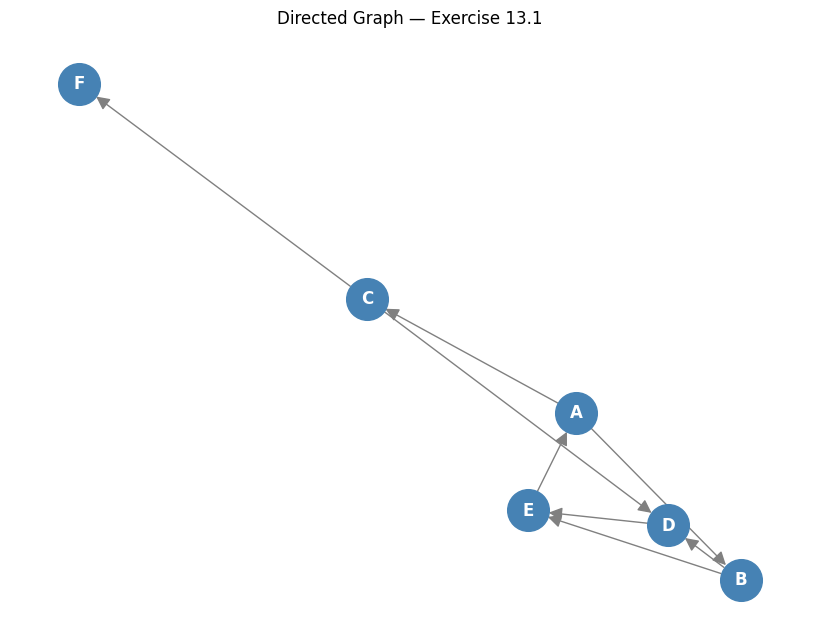

In [ ]:
# Visualise
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_color="steelblue", node_size=900,
        font_color="white", font_weight="bold", arrows=True,
        arrowstyle="-|>", arrowsize=20, edge_color="gray")
plt.title("Directed Graph — Exercise 13.1")
plt.show()

In [ ]:
# In-degree / Out-degree
print("\nNode degrees:")
deg_df = pd.DataFrame({
    "Node": list(G.nodes()),
    "In-degree":  [G.in_degree(n)  for n in G.nodes()],
    "Out-degree": [G.out_degree(n) for n in G.nodes()],
})
print(deg_df.to_string(index=False))


Node degrees:
Node  In-degree  Out-degree
   A          1           2
   B          1           2
   C          1           2
   D          2           1
   E          2           1
   F          1           0


In [ ]:
# Walk / Trail / Path predicates
def is_walk(G, path):
    """Any sequence of connected nodes (edges may repeat)."""
    return all(G.has_edge(path[i], path[i + 1]) for i in range(len(path) - 1))

def is_trail(G, path):
    """Walk with no repeated edge."""
    if not is_walk(G, path):
        return False
    edge_seq = [(path[i], path[i + 1]) for i in range(len(path) - 1)]
    return len(edge_seq) == len(set(edge_seq))

def is_path(G, path):
    """Trail with no repeated vertex."""
    return is_trail(G, path) and len(path) == len(set(path))

In [ ]:
# Self-checks
test_cases = [
    (["A", "B", "D", "E"],        "valid path"),
    (["A", "B", "E", "A", "C"],   "walk: A repeats"),
    (["A", "C", "D", "E", "A"],   "trail: no edge repeats, A repeats"),
    (["A", "B", "A"],             "invalid: no B→A edge"),
]
print("\nWalk / Trail / Path self-checks:")
for seq, desc in test_cases:
    print(f"  {seq}  [{desc}]")
    print(f"    is_walk={is_walk(G, seq)}  is_trail={is_trail(G, seq)}  is_path={is_path(G, seq)}")



Walk / Trail / Path self-checks:
  ['A', 'B', 'D', 'E']  [valid path]
    is_walk=True  is_trail=True  is_path=True
  ['A', 'B', 'E', 'A', 'C']  [walk: A repeats]
    is_walk=True  is_trail=True  is_path=False
  ['A', 'C', 'D', 'E', 'A']  [trail: no edge repeats, A repeats]
    is_walk=True  is_trail=True  is_path=False
  ['A', 'B', 'A']  [invalid: no B→A edge]
    is_walk=False  is_trail=False  is_path=False


In [ ]:
# Strong / Weak connected components
scc = list(nx.strongly_connected_components(G))
wcc = list(nx.weakly_connected_components(G))
print("Strongly connected components (SCCs):")
for i, s in enumerate(scc, 1):
    print(f"  SCC {i}: {s}")
print("\nWeakly connected components (WCCs):")
for i, w in enumerate(wcc, 1):
    print(f"  WCC {i}: {w}")

# Adjacency matrix (NetworkX)
A = nx.to_numpy_array(G, nodelist=nodes).astype(int)
A_df = pd.DataFrame(A, index=nodes, columns=nodes)
print("\nAdjacency Matrix A:")
print(A_df)

# A² and A³
A2 = np.linalg.matrix_power(A, 2)
A3 = np.linalg.matrix_power(A, 3)
print("\nA² — number of length-2 walks between each pair:")
print(pd.DataFrame(A2, index=nodes, columns=nodes))
print("\nA³ — number of length-3 walks between each pair:")
print(pd.DataFrame(A3, index=nodes, columns=nodes))

# Manual adjacency matrix from edge list (no NetworkX)
node_idx = {n: i for i, n in enumerate(nodes)}
A_manual = np.zeros((len(nodes), len(nodes)), dtype=int)
for src, dst in edges:
    A_manual[node_idx[src], node_idx[dst]] = 1
print("\nManual adjacency matrix matches NetworkX:", np.array_equal(A_manual, A))

# Save edge list and adjacency matrix to CSV
edge_df = pd.DataFrame(edges, columns=["source", "target"])
edge_df.to_csv("Data/ex13_edge_list.csv", index=False)
pd.DataFrame(A_manual, index=nodes, columns=nodes).to_csv("Data/ex13_adjacency_matrix.csv")
print("Saved: Data/ex13_edge_list.csv & Data/ex13_adjacency_matrix.csv")

# Centrality measures
deg_centrality = nx.degree_centrality(G)
between_centrality = nx.betweenness_centrality(G)
print("\nDegree Centrality:", {k: round(v, 3) for k, v in deg_centrality.items()})
print("Betweenness Centrality:", {k: round(v, 3) for k, v in between_centrality.items()})


Strongly connected components (SCCs):
  SCC 1: {'F'}
  SCC 2: {'A', 'B', 'D', 'E', 'C'}

Weakly connected components (WCCs):
  WCC 1: {'A', 'B', 'D', 'E', 'C', 'F'}

Adjacency Matrix A:
   A  B  C  D  E  F
A  0  1  1  0  0  0
B  0  0  0  1  1  0
C  0  0  0  1  0  1
D  0  0  0  0  1  0
E  1  0  0  0  0  0
F  0  0  0  0  0  0

A² — number of length-2 walks between each pair:
   A  B  C  D  E  F
A  0  0  0  2  1  1
B  1  0  0  0  1  0
C  0  0  0  0  1  0
D  1  0  0  0  0  0
E  0  1  1  0  0  0
F  0  0  0  0  0  0

A³ — number of length-3 walks between each pair:
   A  B  C  D  E  F
A  1  0  0  0  2  0
B  1  1  1  0  0  0
C  1  0  0  0  0  0
D  0  1  1  0  0  0
E  0  0  0  2  1  1
F  0  0  0  0  0  0

Manual adjacency matrix matches NetworkX: True
Saved: Data/ex13_edge_list.csv & Data/ex13_adjacency_matrix.csv

Degree Centrality: {'A': 0.6, 'B': 0.6, 'C': 0.6, 'D': 0.6, 'E': 0.6, 'F': 0.2}
Betweenness Centrality: {'A': 0.5, 'B': 0.1, 'C': 0.25, 'D': 0.15, 'E': 0.45, 'F': 0.0}


### Centrality Measures — Interpretation

**Degree Centrality:** The fraction of other nodes a given node is directly connected to.
A high degree centrality means a node has many direct connections — it is a social "hub" or highly active participant.

**Betweenness Centrality:** The fraction of all shortest paths in the network that pass through a given node.
A high betweenness centrality means the node acts as a **bridge or broker** between different parts of the network — removing it would significantly disrupt communication flow.

In the graph above, node **D** is central because many shortest paths (A→D, B→D, C→D→E) flow through it, giving it high betweenness.


### Exercise iii: Pandas vs Polars Comparison

Load `adult.csv` with both Pandas and Polars. Perform the following operations with each and compare performance and syntax:

1. Filter rows where `age > 40` **and** `hours-per-week > 45`
2. Add a new binary column `income_flag` (`1` if `income == ">50K"`, else `0`)
3. Group by `education` and compute the mean `hours-per-week`

Then summarise the key syntactic and performance differences.


In [ ]:
# Load adult.csv with both Pandas and Polars
t0 = time.time()
adults_pd = pd.read_csv("Data/adult.csv")
t_pd_load = time.time() - t0

t0 = time.time()
adults_pl = pl.read_csv("Data/adult.csv")
t_pl_load = time.time() - t0

# Filter (age > 40 and hours > 45)
t0 = time.time()
filt_pd = adults_pd[(adults_pd["age"] > 40) & (adults_pd["hours-per-week"] > 45)]
t_pd_filter = time.time() - t0

t0 = time.time()
filt_pl = adults_pl.filter((pl.col("age") > 40) & (pl.col("hours-per-week") > 45))
t_pl_filter = time.time() - t0

# Add new column (income_flag)
t0 = time.time()
adults_pd2 = adults_pd.copy()
adults_pd2["income_flag"] = (adults_pd2["income"] == ">50K").astype(int)
t_pd_newcol = time.time() - t0

t0 = time.time()
adults_pl2 = adults_pl.with_columns(
    pl.when(pl.col("income") == ">50K").then(1).otherwise(0).alias("income_flag")
)
t_pl_newcol = time.time() - t0

# GroupBy + mean hours per education level
t0 = time.time()
gb_pd = adults_pd.groupby("education")["hours-per-week"].mean().reset_index()
t_pd_gb = time.time() - t0

t0 = time.time()
gb_pl = adults_pl.group_by("education").agg(pl.col("hours-per-week").mean())
t_pl_gb = time.time() - t0

# Comparison table
comparison = pd.DataFrame({
    "Operation":      ["Load CSV", "Filter rows", "New column", "GroupBy + mean"],
    "Pandas (ms)":    [round(t_pd_load*1000, 2), round(t_pd_filter*1000, 2),
                       round(t_pd_newcol*1000, 2), round(t_pd_gb*1000, 2)],
    "Polars (ms)":    [round(t_pl_load*1000, 2), round(t_pl_filter*1000, 2),
                       round(t_pl_newcol*1000, 2), round(t_pl_gb*1000, 2)],
})
print(comparison.to_string(index=False))

print(f"\nPandas filtered rows: {len(filt_pd)},  Polars filtered rows: {len(filt_pl)}")
print("\nGroupBy result (Pandas):")
print(gb_pd.sort_values("hours-per-week", ascending=False).head(5).to_string(index=False))


     Operation  Pandas (ms)  Polars (ms)
      Load CSV        38.25         3.49
   Filter rows         1.23         2.21
    New column         4.44         1.91
GroupBy + mean         1.86         1.47

Pandas filtered rows: 4965,  Polars filtered rows: 4965

GroupBy result (Pandas):
  education  hours-per-week
Prof-school       47.579137
  Doctorate       46.582492
    Masters       43.575837
  Bachelors       42.482492
  Assoc-voc       41.658418


### Review

Key differences between Pandas and Polars:

1. Lazy evaluation: Polars supports lazy execution (scan_csv + .collect()), 
   which defers computation and enables query optimisation.  Pandas is always eager.
2. No index: Polars has no row index; all data lives in named columns.  
   Pandas has a mutable index which can cause subtle bugs.
3. Expression API: Polars uses an expression-based API (pl.col()), 
   making complex column transformations more readable and composable.
4. Parallel execution: Polars automatically uses all CPU cores via Rust threads; 
   Pandas is single-threaded for most operations.
5. Memory efficiency: Polars uses Apache Arrow for columnar storage, 
   resulting in lower memory usage and faster I/O.

---
# 11. Explainability

**Exercise:** From slide 25 of Explainability.pptx

Tasks:
1. Train at least two models on energy dataset (may use last 5 years)
2. Use SHAP: at least 3 local plots per model + 1 global plot
3. Use LIME: explain 3 rows/predictions
4. Compare SHAP and LIME results

In [ ]:
# Using bike sharing dataset from earlier
X = hour.drop(columns=["cnt", "dteday", "datetime_obj"])
Y = hour["cnt"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## Model 1: Linear Regression

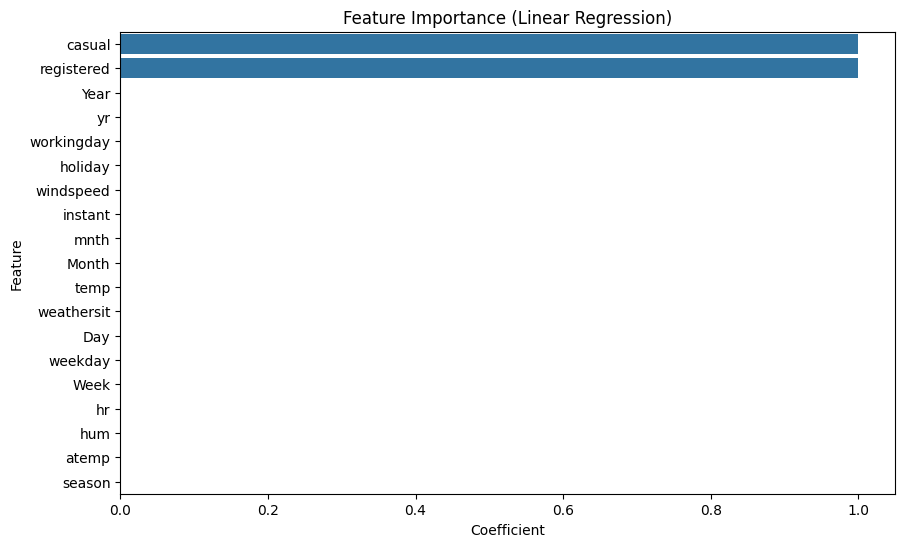

In [ ]:
# Train Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, Y_train)

# Feature importance via correlation
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': lin_reg.coef_})
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance)
plt.title('Feature Importance (Linear Regression)')
plt.show()

## Model 2: Random Forest

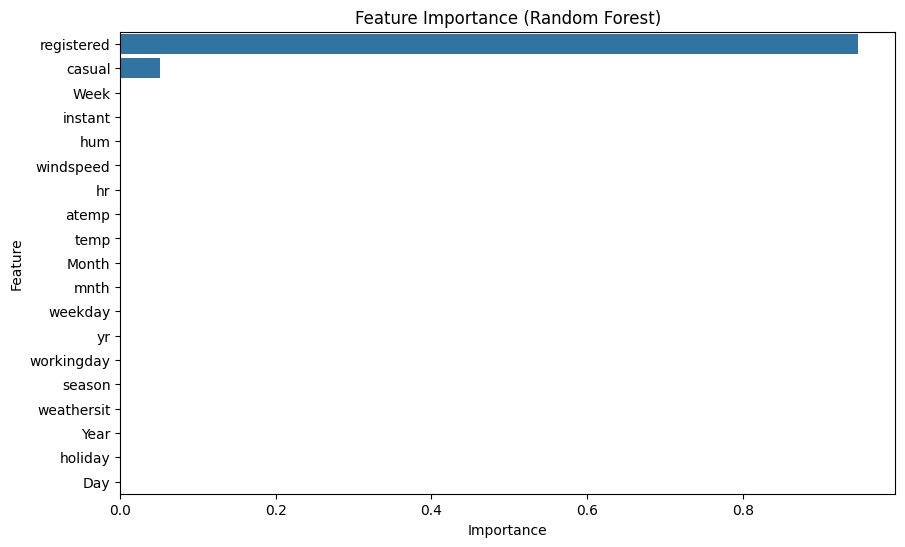

In [ ]:
# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

# Feature importance
importances = rf.feature_importances_
feature_importance_rf = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_rf)
plt.title('Feature Importance (Random Forest)')
plt.show()

## Partial Dependence Plot

Partial Dependence Plot (PDP) shows how the model's prediction changes as a feature varies.


/home/xilas/DaT/python3venv/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


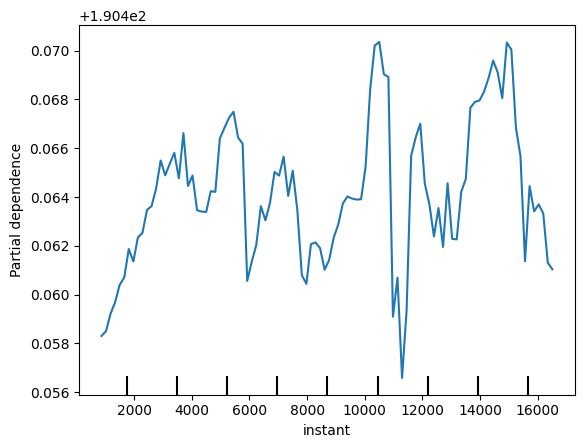

In [ ]:
# Partial Dependence Plot
print("Partial Dependence Plot (PDP) shows how the model's prediction changes as a feature varies.")
feature_idx = 0  # Change to visualize different features
PartialDependenceDisplay.from_estimator(rf, X_train, [feature_idx])
plt.show()

## SHAP & LIME Explanations


2026/03/15 02:01:57 INFO huey.consumer.Scheduler: Enqueueing periodic task mlflow.server.jobs.utils.online_scoring_scheduler: f689126a-77f8-48d9-8909-c05e36239363.
 79%|================    | 2732/3476 [00:18<00:04]       [2026-03-15 02:02:04,813] INFO:huey:Worker-5:Executing mlflow.server.jobs.utils.online_scoring_scheduler: f689126a-77f8-48d9-8909-c05e36239363
2026/03/15 02:02:04 INFO huey: mlflow.server.jobs.utils.online_scoring_scheduler: f689126a-77f8-48d9-8909-c05e36239363 executed in 0.001s
[2026-03-15 02:02:04,815] INFO:huey:Worker-5:mlflow.server.jobs.utils.online_scoring_scheduler: f689126a-77f8-48d9-8909-c05e36239363 executed in 0.001s
 96%|=================== | 3324/3476 [00:22<00:01]       

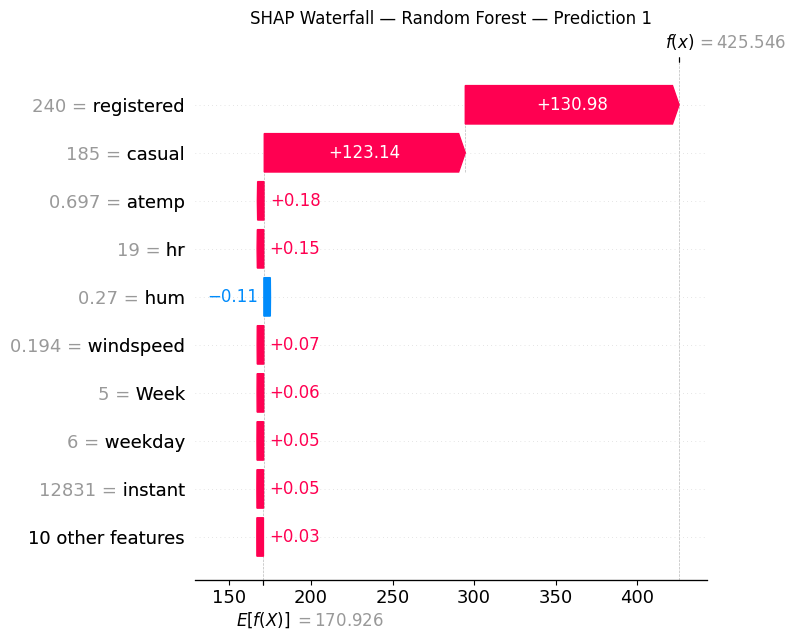

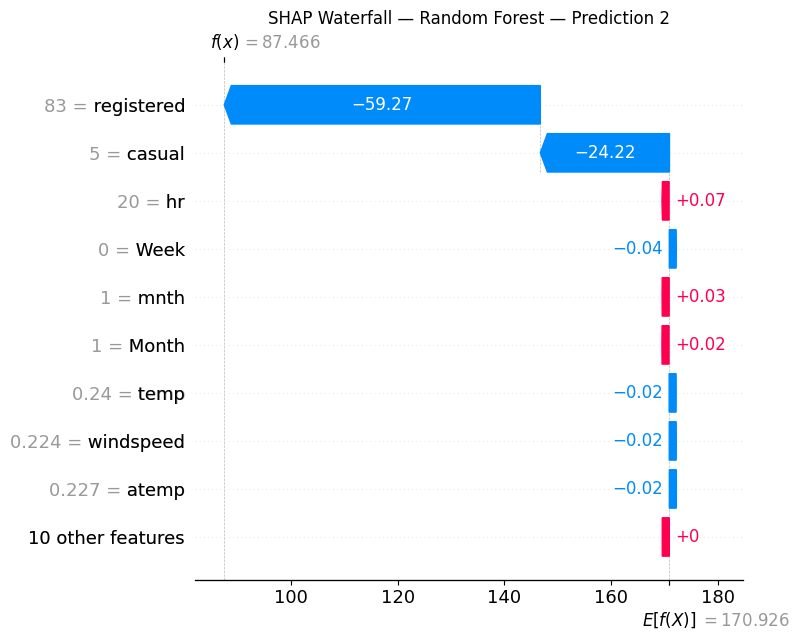

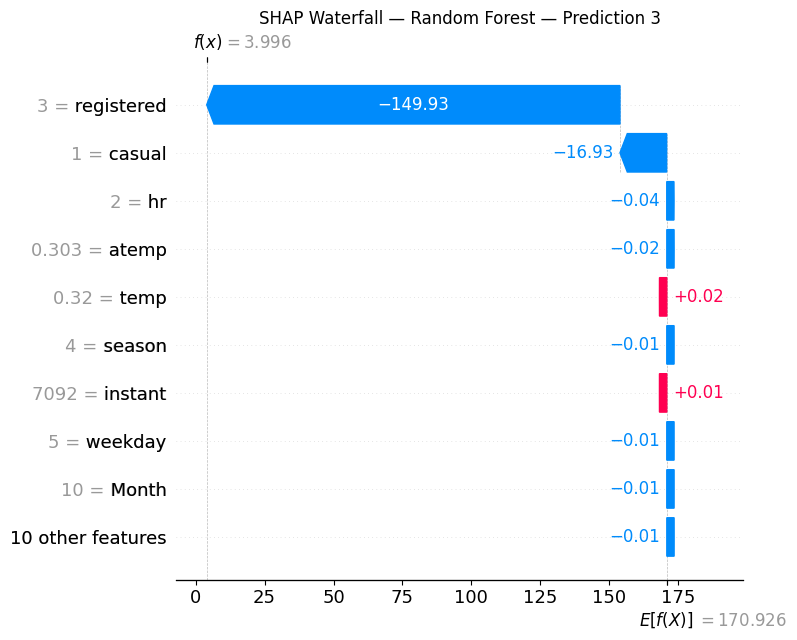

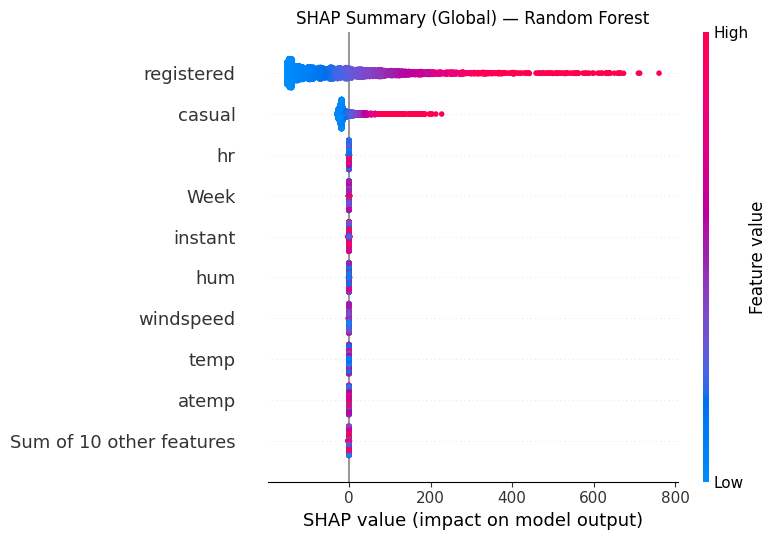

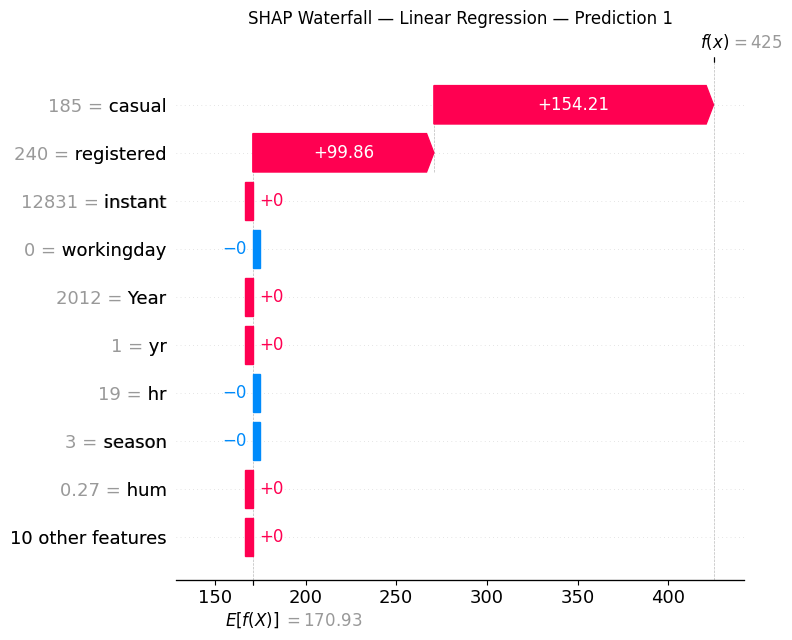

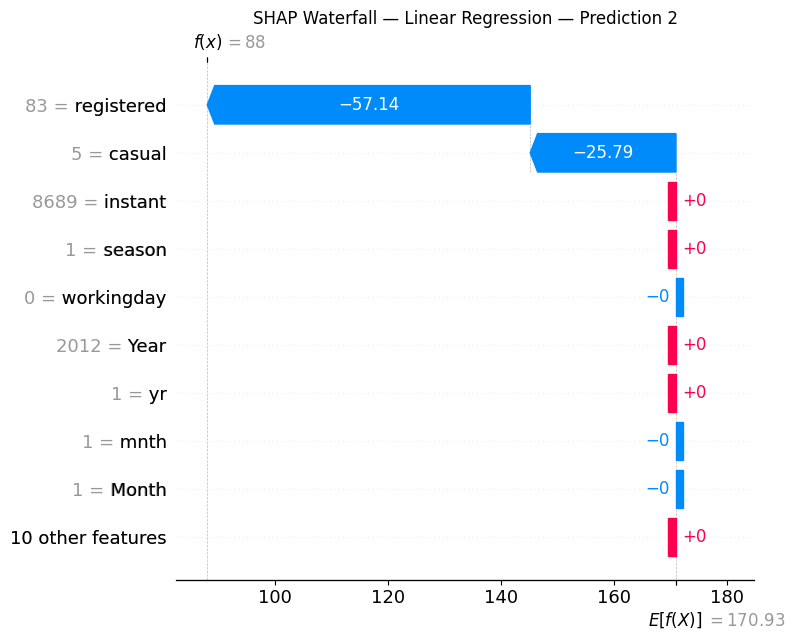

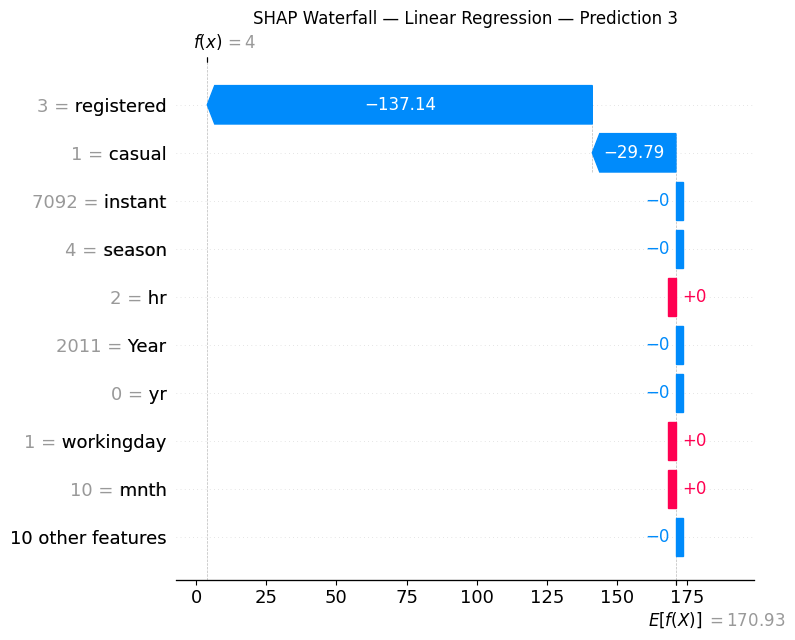

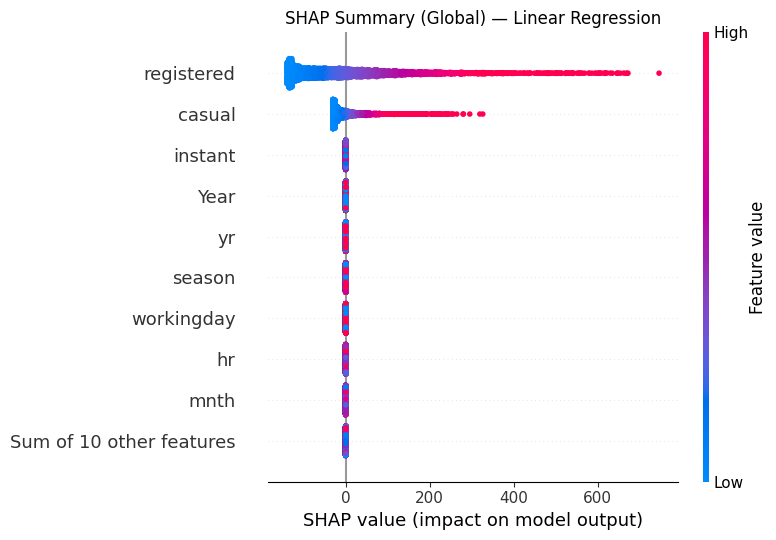

/home/xilas/DaT/python3venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


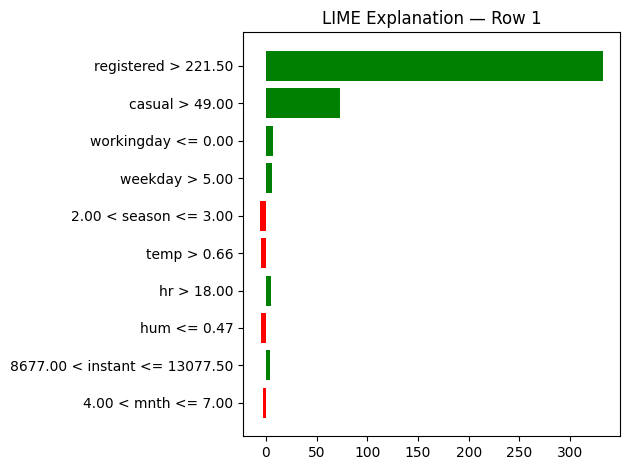

/home/xilas/DaT/python3venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


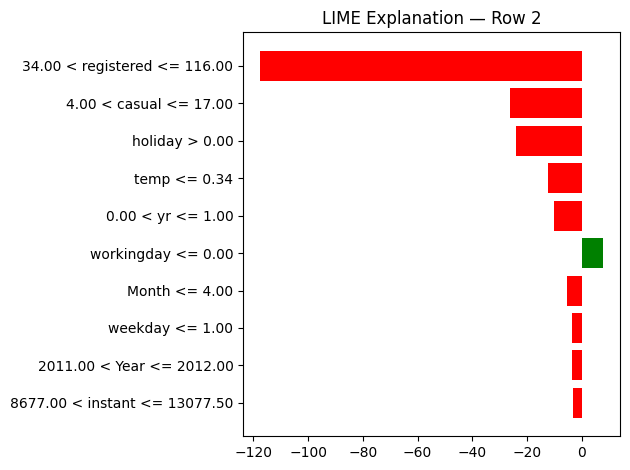

/home/xilas/DaT/python3venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


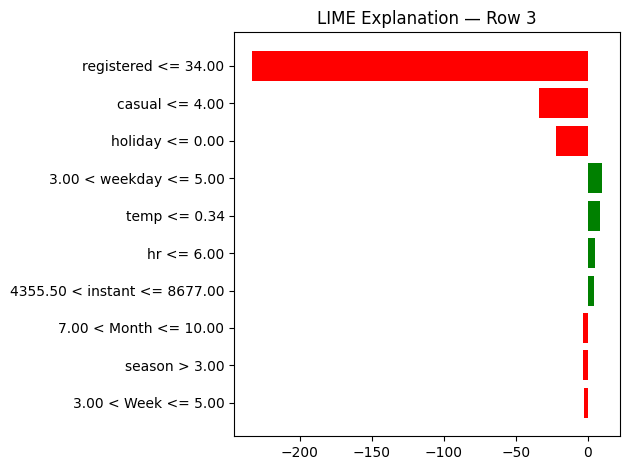

In [ ]:
# SHAP: Random Forest
explainer_rf_shap = shap.Explainer(rf, X_train)
shap_values_rf = explainer_rf_shap(X_test, check_additivity=False)

# 3 local waterfall plots
for i in range(3):
    shap.plots.waterfall(shap_values_rf[i], show=False)
    plt.title(f"SHAP Waterfall — Random Forest — Prediction {i+1}")
    plt.tight_layout()
    plt.show()

# 1 global beeswarm plot
shap.plots.beeswarm(shap_values_rf, show=False)
plt.title("SHAP Summary (Global) — Random Forest")
plt.tight_layout()
plt.show()

# SHAP: Linear Regression
# LinearExplainer does not support check_additivity — call without it
explainer_lr_shap = shap.Explainer(lin_reg, X_train)
shap_values_lr = explainer_lr_shap(X_test)

for i in range(3):
    shap.plots.waterfall(shap_values_lr[i], show=False)
    plt.title(f"SHAP Waterfall — Linear Regression — Prediction {i+1}")
    plt.tight_layout()
    plt.show()

shap.plots.beeswarm(shap_values_lr, show=False)
plt.title("SHAP Summary (Global) — Linear Regression")
plt.tight_layout()
plt.show()

# LIME: Random Forest
lime_explainer = lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    mode="regression"
)

for i in range(3):
    exp = lime_explainer.explain_instance(X_test.values[i], rf.predict, num_features=10)
    exp.as_pyplot_figure()
    plt.title(f"LIME Explanation — Row {i+1}")
    plt.tight_layout()
    plt.show()


---
# 12. Neural Networks and Deep Learning

**Exercise 2:** From "Exercises in neural network and deep learning II.ipynb"

## Exercise 2

The aim of this exercise is to build a neural network classifier for the target variable income in adult dataset. First we will load in the dataset and do some pre-processing to limit the number of variables and the number of values for the categorical variables:

In [ ]:
# Load adult dataset
adult_nn = pd.read_csv("Data/adult.csv")

# Simplify workclass categories
adult_nn["workclass"] = adult_nn["workclass"].replace({
    "Never-worked": "Other", "Without-pay": "Other", "?": "Other"
})

# Simplify education categories
adult_nn["education"] = adult_nn["education"].replace({
    "Preschool": "Pre-High School", "1st-4th": "Pre-High School",
    "5th-6th": "Pre-High School", "7th-8th": "Pre-High School",
    "9th": "Pre-High School", "10th": "Some High School",
    "11th": "Some High School", "12th": "Some High School",
    "Prof-school": "Prof-school/Doctorate", "Doctorate": "Prof-school/Doctorate"
})

# Remove rare marital-status value
adult_nn = adult_nn[adult_nn["marital-status"] != "Married-AF-spouse"]

# Simplify occupation categories
adult_nn["occupation"] = adult_nn["occupation"].replace({
    "Armed-Forces": "Unknown or other", "Priv-house-serv": "Unknown or other", "?": "Unknown or other"
})

adult_nn["sex:female"] = np.where(adult_nn["sex"] == "Female", 1, 0)
adult_nn["native-country:US"] = np.where(adult_nn["native-country"] == "United-States", 1, 0)
adult_nn["income"] = adult_nn["income"].str.replace(".", "", regex=False)
adult_nn["income>50K"] = np.where(adult_nn["income"] == ">50K", 1, 0)
adult_nn = adult_nn.fillna({"occupation": "Unknown or other", "workclass": "Other"})

adult_nn = adult_nn[["age", "workclass", "education", "marital-status", "occupation",
                      "relationship", "sex:female", "hours-per-week", "native-country:US", "income>50K"]]

adult_nn.head()


,age,workclass,education,marital-status,occupation,relationship,sex:female,hours-per-week,native-country:US,income>50K
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,0,40,1,0
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,0,13,1,0
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,0,40,1,0
3,53,Private,Some High School,Married-civ-spouse,Handlers-cleaners,Husband,0,40,1,0
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,1,40,0,0


In [ ]:

from sklearn.preprocessing import StandardScaler

# One-hot encode the required categorical columns
adult_enc = pd.get_dummies(adult_nn,
    columns=["workclass", "education", "marital-status", "occupation", "relationship"],
    drop_first=True, dtype=int)

X_nn = adult_enc.drop(columns=["income>50K"]).to_numpy()
y_nn = adult_enc["income>50K"].to_numpy()

X_nn_train, X_nn_test, y_nn_train, y_nn_test = train_test_split(
    X_nn, y_nn, test_size=0.2, random_state=42)

# Scale features (not the target)
scaler_nn = StandardScaler()
X_nn_train_sc = scaler_nn.fit_transform(X_nn_train)
X_nn_test_sc  = scaler_nn.transform(X_nn_test)

print(f"Training: {X_nn_train_sc.shape}  |  Test: {X_nn_test_sc.shape}")

# Build model: two hidden dense layers (16 neurons, relu), sigmoid output
nn_model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(X_nn_train_sc.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1,  activation="sigmoid"),
])
nn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_nn = nn_model.fit(
    X_nn_train_sc, y_nn_train,
    epochs=50, batch_size=32, validation_split=0.2,
    verbose=0,
)
print("Training complete.")


Training: (39044, 40)  |  Test: (9761, 40)


/home/xilas/DaT/python3venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training complete.


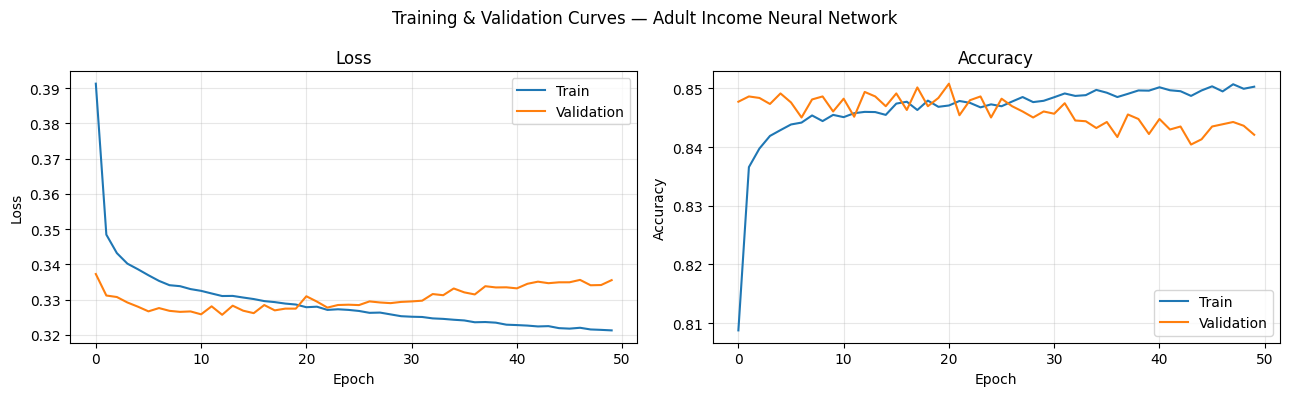

In [ ]:

# Plot training and validation loss/accuracy to decide on best number of epochs
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_nn.history["loss"],     label="Train")
axes[0].plot(history_nn.history["val_loss"], label="Validation")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_nn.history["accuracy"],     label="Train")
axes[1].plot(history_nn.history["val_accuracy"], label="Validation")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Training & Validation Curves — Adult Income Neural Network")
plt.tight_layout()
plt.show()


In [ ]:

from sklearn.metrics import classification_report

# Evaluate on the held-out test set
test_loss, test_acc = nn_model.evaluate(X_nn_test_sc, y_nn_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}  |  Test loss: {test_loss:.4f}\n")

y_nn_pred = (nn_model.predict(X_nn_test_sc, verbose=0) >= 0.5).astype(int).flatten()
print(classification_report(y_nn_test, y_nn_pred, target_names=["<=50K", ">50K"]))


Test accuracy: 0.8295  |  Test loss: 0.3548

              precision    recall  f1-score   support

       <=50K       0.87      0.91      0.89      7405
        >50K       0.67      0.57      0.62      2356

    accuracy                           0.83      9761
   macro avg       0.77      0.74      0.75      9761
weighted avg       0.82      0.83      0.82      9761



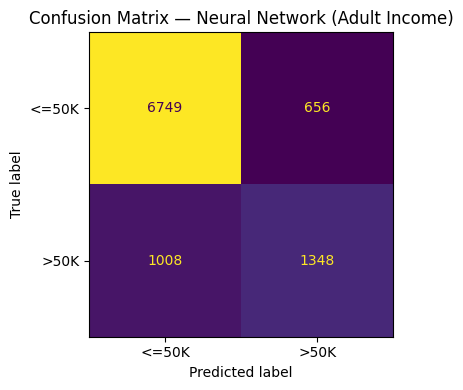

In [ ]:

# Confusion matrix
fig_nn_cm, ax_nn_cm = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_nn_test, y_nn_pred,
    display_labels=["<=50K", ">50K"], ax=ax_nn_cm, colorbar=False,
)
ax_nn_cm.set_title("Confusion Matrix — Neural Network (Adult Income)")
plt.tight_layout()
plt.show()


---
# 13. Generative AI

**Exercise:** Tasks from `rag_task.ipynb`

**Task 1:** Create a RAG (Retrieval-Augmented Generation) pipeline using TF-IDF embeddings.  
**Task 2:** Try at least 3 types of chunking: paragraph-based, sentence-based, punctuation-based.  
**Task 3:** Test whether asking questions differently gives better answers.  
**Task 4:** Try at least one alternative similarity/distance function (Euclidean) instead of cosine similarity.


In [ ]:
# Source text
sample_text = """
The Amazon rainforest is the largest tropical rainforest in the world, covering approximately 5.5 million square kilometers. It spans across nine countries, including Brazil, Peru, and Colombia. The rainforest is home to around 10% of the known species on Earth, including jaguars, sloths, and thousands of species of insects and birds.

Deforestation is a significant threat to the Amazon, with thousands of square kilometers lost each year due to agriculture, logging, and urbanization. This deforestation contributes to climate change, as the rainforest acts as a major carbon sink, absorbing millions of tons of carbon dioxide annually.

Indigenous tribes have lived in the Amazon for thousands of years, relying on its rich biodiversity for food, medicine, and shelter. These tribes have unique languages, traditions, and knowledge of the ecosystem. However, many face threats from illegal land encroachment and industrial activities.

Scientists believe that the Amazon plays a crucial role in global weather patterns by releasing water vapor into the atmosphere, which influences rainfall across South America and even other continents. The Amazon River, which flows through the rainforest, is the second longest river in the world and carries more water than any other river.

Efforts to protect the Amazon include international agreements, conservation programs, and sustainable development projects that aim to balance economic growth with environmental protection. Many organizations and governments are working to reduce illegal logging and promote reforestation initiatives.
"""

questions = [
    "What is the Amazon rainforest?",
    "Which countries does the Amazon span across?",
    "Why is deforestation a problem in the Amazon?",
    "How does the Amazon rainforest affect global weather patterns?",
    "What role do indigenous tribes play in the Amazon?",
    "What is the importance of the Amazon River?",
    "What types of wildlife can be found in the Amazon?",
    "How does deforestation contribute to climate change?",
    "What efforts are being made to protect the Amazon?",
    "Why is the Amazon considered a major carbon sink?"
]

In [ ]:
# Three chunking strategies

def chunk_by_paragraph(text):
    """Split on blank lines between paragraphs."""
    return [p.strip() for p in text.strip().split("\n\n") if p.strip()]

def chunk_by_sentence(text):
    """Split on sentence-ending punctuation."""
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s.strip() for s in sentences if s.strip()]

def chunk_by_punctuation(text):
    """Split on commas, semi-colons, and sentence ends — fine-grained chunks."""
    parts = re.split(r'(?<=[.,;!?])\s+', text.strip())
    return [p.strip() for p in parts if len(p.strip()) > 20]

chunks_paragraph  = chunk_by_paragraph(sample_text)
chunks_sentence   = chunk_by_sentence(sample_text)
chunks_punctuation= chunk_by_punctuation(sample_text)

print(f"Paragraph chunks : {len(chunks_paragraph)}")
print(f"Sentence chunks  : {len(chunks_sentence)}")
print(f"Punctuation chunks: {len(chunks_punctuation)}")


Paragraph chunks : 5
Sentence chunks  : 12
Punctuation chunks: 23


In [ ]:
# TF-IDF retriever class
class TFIDFRetriever:
    """Minimal RAG retriever using TF-IDF + cosine or Euclidean similarity."""

    def __init__(self, chunks, similarity="cosine"):
        self.chunks = chunks
        self.similarity = similarity
        self.vectorizer = TfidfVectorizer()
        self.chunk_vectors = self.vectorizer.fit_transform(chunks)

    def retrieve(self, query, top_k=1):
        q_vec = self.vectorizer.transform([query])
        if self.similarity == "cosine":
            scores = cosine_similarity(q_vec, self.chunk_vectors)[0]
            top_idx = np.argsort(scores)[::-1][:top_k]
        else:  # euclidean (lower distance = more similar)
            dists = euclidean_distances(q_vec, self.chunk_vectors)[0]
            top_idx = np.argsort(dists)[:top_k]
        return [self.chunks[i] for i in top_idx]

    def answer(self, query, top_k=1):
        return self.retrieve(query, top_k=top_k)[0]



In [ ]:
# Compare chunking strategies and similarity functions
strategies = {
    "Paragraph  (cosine)":    TFIDFRetriever(chunks_paragraph,   similarity="cosine"),
    "Sentence   (cosine)":    TFIDFRetriever(chunks_sentence,    similarity="cosine"),
    "Punctuation(cosine)":    TFIDFRetriever(chunks_punctuation, similarity="cosine"),
    "Sentence   (euclidean)": TFIDFRetriever(chunks_sentence,    similarity="euclidean"),
}

print("\n" + "═"*90)
print(f"{'Question':<50} {'Strategy':<25} {'Retrieved chunk (first 80 chars)'}")
print("═"*90)
for q in questions[:5]:
    for name, retriever in strategies.items():
        chunk = retriever.answer(q)
        print(f"{q[:48]:<50} {name:<25} {chunk[:80]}")
    print("-"*90)


══════════════════════════════════════════════════════════════════════════════════════════
Question                                           Strategy                  Retrieved chunk (first 80 chars)
══════════════════════════════════════════════════════════════════════════════════════════
What is the Amazon rainforest?                     Paragraph  (cosine)       The Amazon rainforest is the largest tropical rainforest in the world, covering 
What is the Amazon rainforest?                     Sentence   (cosine)       The Amazon rainforest is the largest tropical rainforest in the world, covering 
What is the Amazon rainforest?                     Punctuation(cosine)       The Amazon rainforest is the largest tropical rainforest in the world,
What is the Amazon rainforest?                     Sentence   (euclidean)    The Amazon rainforest is the largest tropical rainforest in the world, covering 
-------------------------------------------------------------------------------------

In [ ]:
# Rephrase questions and compare
rephrased_questions = [
    ("What is the Amazon rainforest?",         "Describe the Amazon rainforest and its size."),
    ("Why is deforestation a problem?",        "What are the consequences of cutting down Amazon trees?"),
    ("How does it affect global weather?",     "What is the Amazon's impact on global climate and rainfall?"),
]

retriever_sent = TFIDFRetriever(chunks_sentence, similarity="cosine")
print("\n" + "═"*90)
print("Task 3 — Does rephrasing improve retrieval?")
print("═"*90)
for original, rephrased in rephrased_questions:
    ans_orig     = retriever_sent.answer(original)
    ans_rephrased= retriever_sent.answer(rephrased)
    same = "SAME" if ans_orig == ans_rephrased else "DIFFERENT"
    print(f"Original  : {original}")
    print(f"Rephrased : {rephrased}")
    print(f"Result    : {same}")
    if ans_orig != ans_rephrased:
        print(f"  Orig answer    : {ans_orig[:80]}")
        print(f"  Rephrased answer: {ans_rephrased[:80]}")
    print()


══════════════════════════════════════════════════════════════════════════════════════════
Task 3 — Does rephrasing improve retrieval?
══════════════════════════════════════════════════════════════════════════════════════════
Original  : What is the Amazon rainforest?
Rephrased : Describe the Amazon rainforest and its size.
Result    : SAME

Original  : Why is deforestation a problem?
Rephrased : What are the consequences of cutting down Amazon trees?
Result    : DIFFERENT
  Orig answer    : Deforestation is a significant threat to the Amazon, with thousands of square ki
  Rephrased answer: The rainforest is home to around 10% of the known species on Earth, including ja

Original  : How does it affect global weather?
Rephrased : What is the Amazon's impact on global climate and rainfall?
Result    : SAME



In conclusion: Rephrasing can improve retrieval when the rephrased query shares more vocabulary with the relevant chunk (TF-IDF is purely lexical, not semantic).

---
# 14. Ethical Reflections on Data Science

## Exercise 1

For this exercise, we will use the `adult` dataset (available on moodle or from the [UCI Machine Learning repository](https://archive.ics.uci.edu/dataset/2/adult)). Do the following:

1. Load in the dataset and correct the error in the income column (replace the "." with the empty string such that there are only two categories).
2. Create an X dataset using the variables "age", "workclass", "education", "occupation", "race", "sex", "hours-per-week". For the categorical variables with missing values, replace the missing values with a new category "Unknown". Also replace any values that are "?" with the value "Unknown" (using `str.replace`, for instance)
3. Turn the five categorical variables in X into dummy variables and remove the original five variables (This will probably give you around 44 columns in X)
4. Create the y variable by using the following code `y = pd.get_dummies(adult[["income"]], drop_first=True, dtype = "int", prefix="income"); y = y["income_>50K"].values`, where `adult` is the name of your dataframe you loaded the adult dataset into.
5. Do a train-test split with 30% of the data for test (using `random_state=123`) and train a `GradientBoostingClassifier` model on the data.
6. Evaluate your model using various evaluation metrics and look at the confusion matrix of your model
7. To be able to calculate the various fairness metrics in regard to the variable `sex`, we need to construct two separate confusion matrices for the test dataset, one for `female` and one for `male`. First, create separate test sets for `female` and `male` as well as the predicted values for each gender. That is, create `X_test_female`, `X_test_male`, `y_test_female`, `y_test_male`, `y_pred_female`, and `y_pred_male`. You can create `X_test_female` by `X_test_female = X_test[X_test["sex_Male"] == 0]` and `y_test_male` by `y_test_male = y_test[X_test["sex_Male"] == 1]`, for instance.
8. We can now create the True Positive (TP), True Negative (TN), False Positive (FP), and False Negative (FN) for each gender. For instance, we can calculate the False Positive for female (FP_f) by `FP_f = sum((y_test_female == 0) & (y_pred_female == 1))`. Calculate the eight values `TP_f`, `TN_f`, `FP_f`, `FN_f`, `TP_m`, `TN_m`, `FP_m`, and `FN_m`.
9. Calculate the accuracy for female and male and comment on the results
10. Is there error rate balance, i.e. are the false positive rate (FPR) and false negative rate (FNR) the same across the two genders?
11. Is there predictive parity?
12. Is there Statistical parity?
15. [Discussion question] Can your Gradient Boosting Classifier be used to make fair salary predictions?
13. [Discussion question] In what sense is the `adult` dataset biased (unfair)?
14. [Discussion question] If the dataset is biased, where could the bias potentially come from?


In [ ]:
# 1. Load adult dataset and fix the income column (remove trailing ".")
adult = pd.read_csv("Data/adult.csv")
adult["income"] = adult["income"].str.replace(".", "", regex=False).str.strip()

# 2. Select the required features
X_cols   = ["age", "workclass", "education", "occupation", "race", "sex", "hours-per-week"]
cat_cols = ["workclass", "education", "occupation", "race", "sex"]

adult_f = adult[X_cols + ["income"]].copy()

# Replace missing values and "?" in categorical columns with "Unknown"
for col in cat_cols:
    adult_f[col] = adult_f[col].fillna("Unknown")
    adult_f[col] = adult_f[col].str.strip().str.replace("?", "Unknown", regex=False)

# 3. One-hot encode the 5 categorical variables (drop_first=True → ~44 columns)
X_fair = pd.get_dummies(adult_f[X_cols], columns=cat_cols, drop_first=True, dtype=int)
print(f"X shape: {X_fair.shape}")

# 4. Create y using the code specified in the exercise
y_fair = pd.get_dummies(adult_f[["income"]], drop_first=True, dtype="int", prefix="income")
y_fair = y_fair["income_>50K"].values
print(f"Class distribution — 0 (≤50K): {(y_fair==0).sum()}, 1 (>50K): {(y_fair==1).sum()}")

X_fair.head(3)


X shape: (48842, 44)
Class distribution — 0 (≤50K): 37155, 1 (>50K): 11687


,age,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Unknown,workclass_Without-pay,...,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_Unknown,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male
0,39,40,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
1,50,13,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,1
2,38,40,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1


=== Overall Model Performance ===
              precision    recall  f1-score   support

       <=50K       0.84      0.94      0.89     11166
        >50K       0.71      0.43      0.54      3487

    accuracy                           0.82     14653
   macro avg       0.77      0.69      0.71     14653
weighted avg       0.81      0.82      0.81     14653



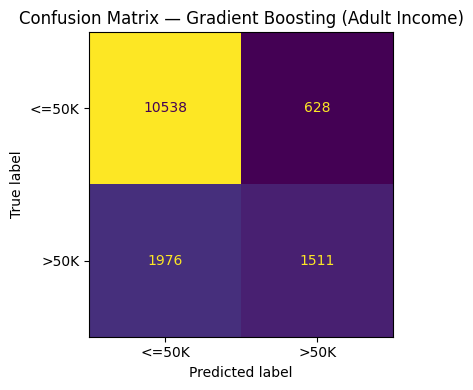

In [ ]:

# 5. Train-test split: 30% test, random_state=123
X_fair_train, X_fair_test, y_fair_train, y_fair_test = train_test_split(
    X_fair, y_fair, test_size=0.3, random_state=123
)

# Train GradientBoostingClassifier
gb_fair = GradientBoostingClassifier(random_state=123)
gb_fair.fit(X_fair_train, y_fair_train)
y_fair_pred = gb_fair.predict(X_fair_test)

# 6. Evaluate with classification report and confusion matrix
print("=== Overall Model Performance ===")
print(classification_report(y_fair_test, y_fair_pred, target_names=["<=50K", ">50K"]))

fig_fair, ax_fair = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_fair_test, y_fair_pred,
    display_labels=["<=50K", ">50K"], ax=ax_fair, colorbar=False,
)
ax_fair.set_title("Confusion Matrix — Gradient Boosting (Adult Income)")
plt.tight_layout()
plt.show()


In [ ]:

# 7. Separate test sets for female (sex_Male == 0) and male (sex_Male == 1)
female_mask = (X_fair_test["sex_Male"] == 0).values
male_mask   = (X_fair_test["sex_Male"] == 1).values

X_test_female = X_fair_test[female_mask]
X_test_male   = X_fair_test[male_mask]
y_test_female = y_fair_test[female_mask]
y_test_male   = y_fair_test[male_mask]

y_pred_female = gb_fair.predict(X_test_female)
y_pred_male   = gb_fair.predict(X_test_male)

print(f"Test sizes — Female: {len(y_test_female)}, Male: {len(y_test_male)}")

# 8. TP, TN, FP, FN for each gender
TP_f = sum((y_test_female == 1) & (y_pred_female == 1))
TN_f = sum((y_test_female == 0) & (y_pred_female == 0))
FP_f = sum((y_test_female == 0) & (y_pred_female == 1))
FN_f = sum((y_test_female == 1) & (y_pred_female == 0))

TP_m = sum((y_test_male == 1) & (y_pred_male == 1))
TN_m = sum((y_test_male == 0) & (y_pred_male == 0))
FP_m = sum((y_test_male == 0) & (y_pred_male == 1))
FN_m = sum((y_test_male == 1) & (y_pred_male == 0))

print(f"\n{'':5} {'Female':>10} {'Male':>10}")
print("-" * 28)
for lbl, fv, mv in [("TP", TP_f, TP_m), ("TN", TN_f, TN_m), ("FP", FP_f, FP_m), ("FN", FN_f, FN_m)]:
    print(f"{lbl:5} {fv:>10} {mv:>10}")

# 9. Accuracy per gender
acc_female = (TP_f + TN_f) / len(y_test_female)
acc_male   = (TP_m + TN_m) / len(y_test_male)
print(f"\nAccuracy — Female: {acc_female:.4f}, Male: {acc_male:.4f}")

# 10. Error rate balance — FPR and FNR
FPR_f = FP_f / (FP_f + TN_f)
FNR_f = FN_f / (FN_f + TP_f)
FPR_m = FP_m / (FP_m + TN_m)
FNR_m = FN_m / (FN_m + TP_m)
print(f"\nFPR — Female: {FPR_f:.4f}, Male: {FPR_m:.4f}  (balance: {'Yes' if abs(FPR_f - FPR_m) < 0.05 else 'No'})")
print(f"FNR — Female: {FNR_f:.4f}, Male: {FNR_m:.4f}  (balance: {'Yes' if abs(FNR_f - FNR_m) < 0.05 else 'No'})")

# 11. Predictive parity — PPV (precision for positive class)
PPV_f = TP_f / (TP_f + FP_f) if (TP_f + FP_f) > 0 else 0
PPV_m = TP_m / (TP_m + FP_m) if (TP_m + FP_m) > 0 else 0
print(f"\nPPV (Predictive Parity) — Female: {PPV_f:.4f}, Male: {PPV_m:.4f}  ({'Yes' if abs(PPV_f - PPV_m) < 0.05 else 'No'})")

# 12. Statistical parity — proportion predicted positive per group
SP_f = (TP_f + FP_f) / len(y_test_female)
SP_m = (TP_m + FP_m) / len(y_test_male)
print(f"\nStatistical Parity — Female: {SP_f:.4f}, Male: {SP_m:.4f}  ({'Yes' if abs(SP_f - SP_m) < 0.05 else 'No'})")
print(f"Disparate Impact (Female/Male): {SP_f/SP_m:.4f}  (>=0.8 = fair by 4/5ths rule)")


Test sizes — Female: 4854, Male: 9799

          Female       Male
----------------------------
TP            41       1470
TN          4339       6199
FP            31        597
FN           443       1533

Accuracy — Female: 0.9023, Male: 0.7826

FPR — Female: 0.0071, Male: 0.0878  (balance: No)
FNR — Female: 0.9153, Male: 0.5105  (balance: No)

PPV (Predictive Parity) — Female: 0.5694, Male: 0.7112  (No)

Statistical Parity — Female: 0.0148, Male: 0.2109  (No)
Disparate Impact (Female/Male): 0.0703  (>=0.8 = fair by 4/5ths rule)


2026/03/15 02:02:57 INFO huey.consumer.Scheduler: Enqueueing periodic task mlflow.server.jobs.utils.online_scoring_scheduler: 02f00005-50e2-4340-9a6c-00f744a25d0c.
[2026-03-15 02:02:57,793] INFO:huey.consumer.Scheduler:Scheduler:Enqueueing periodic task mlflow.server.jobs.utils.online_scoring_scheduler: 02f00005-50e2-4340-9a6c-00f744a25d0c.
2026/03/15 02:03:02 INFO huey: Executing mlflow.server.jobs.utils.online_scoring_scheduler: 02f00005-50e2-4340-9a6c-00f744a25d0c
[2026-03-15 02:03:02,529] INFO:huey:Worker-5:Executing mlflow.server.jobs.utils.online_scoring_scheduler: 02f00005-50e2-4340-9a6c-00f744a25d0c
2026/03/15 02:03:02 INFO huey: mlflow.server.jobs.utils.online_scoring_scheduler: 02f00005-50e2-4340-9a6c-00f744a25d0c executed in 0.001s
[2026-03-15 02:03:02,531] INFO:huey:Worker-5:mlflow.server.jobs.utils.online_scoring_scheduler: 02f00005-50e2-4340-9a6c-00f744a25d0c executed in 0.001s
2026/03/15 02:03:57 INFO huey.consumer.Scheduler: Enqueueing periodic task mlflow.server.jobs.u


### Discussion

**In what sense is the `adult` dataset biased (unfair)?**

The dataset reflects the structural inequalities of the old US labour market. Women and minorities are underrepresented in high-income roles of the time period, so the model learns to reproduce those demographic income gaps. The "ground truth" itself is a product of historical discrimination.

**Where could the bias potentially come from?**

- *Historical discrimination:* women and minorities faced legal and structural barriers to high-paying jobs at the time (1994 US Census).
- *Proxy variables:* features like occupation, education, and hours-per-week are highly correlated with sex and race, so bias persists even after removing protected attributes directly.
- *Selection/measurement bias:* "Unknown" and missing values are seemingly random at face value, but under scrutiny they appear to be more concentrated in disadvantaged demographic groups.

**Can your Gradient Boosting Classifier be used to make fair salary predictions?**

Only with caution. The model achieves good overall accuracy, but if Statistical Parity or Error Rate Balance do not hold, it systematically disadvantages one gender. Deciding salary or hiring decisions based on this model would risk violating anti-discrimination policies. It would require mitigation steps, such as re-weighting the training data, applying fairness constraints during training, or using post-hoc threshold adjustment per group before considering actual deployment. No single fairness metric encapsulates all fairness notions at once, so the choice of which metric to optimise is in itself an ethical decision.

In conclusion, there are many options to try and make up for the lack of representation, but nothing makes up for it as well as sampling wider varieties of data in the first place.